<a href="https://colab.research.google.com/github/225K3125/computer_vision_oscar/blob/main/notebooks/oscar_jimenez_analisis_imagenes_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Carga del Dataset

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cv2
import torch
from scipy.ndimage import gaussian_filter, median_filter
from sklearn.metrics.pairwise import cosine_similarity
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, random_split
from collections import Counter

# Configuración común del notebook
CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR100_STD  = (0.2675, 0.2565, 0.2761)
SEED = 42
VAL_RATIO = 0.20
BATCH_SIZE = 64
NUM_WORKERS = 2

# Transformaciones base
transform_raw = transforms.ToTensor()
transform_eval = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR100_MEAN, std=CIFAR100_STD),
])
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR100_MEAN, std=CIFAR100_STD),
])

def denormalize(tensor):
    mean = torch.tensor(CIFAR100_MEAN, dtype=tensor.dtype, device=tensor.device).view(3, 1, 1)
    std = torch.tensor(CIFAR100_STD, dtype=tensor.dtype, device=tensor.device).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

def tensor_to_numpy(image, normalized=False):
    if normalized:
        image = denormalize(image)
    return image.detach().cpu().permute(1, 2, 0).numpy()

def get_label_counts(dataset_or_subset, n_classes=100):
    if isinstance(dataset_or_subset, Subset):
        labels = np.array(dataset_or_subset.dataset.targets)[dataset_or_subset.indices]
    else:
        labels = np.array(dataset_or_subset.targets)
    return np.bincount(labels, minlength=n_classes)

def build_processed_transform(process_fn):
    return transforms.Compose([
        transforms.Lambda(lambda pil_img: np.array(pil_img)),
        transforms.Lambda(process_fn),
        transforms.Lambda(lambda img: torch.from_numpy(img).permute(2, 0, 1).float() / 255.0),
        transforms.Normalize(mean=CIFAR100_MEAN, std=CIFAR100_STD),
    ])

# Datasets base compartidos
full_train_raw = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_raw)
full_test_raw = datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_raw)
train_dataset = datasets.CIFAR100(root='./data', train=True, download=False, transform=transform_eval)
test_dataset = datasets.CIFAR100(root='./data', train=False, download=False, transform=transform_eval)

classes = full_train_raw.classes
targets = np.array(full_train_raw.targets)
images_all = np.array(full_train_raw.data)

# DataLoaders base
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Info básica
print(f"Clases     : {len(classes)}")
print(f"Train size : {len(train_dataset)}")
print(f"Test size  : {len(test_dataset)}")

# Ver un batch
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")   # [64, 3, 32, 32]
print(f"Labels     : {labels[:8]}")

100%|██████████| 169M/169M [00:05<00:00, 29.2MB/s]


Clases     : 100
Train size : 50000
Test size  : 10000
Batch shape: torch.Size([64, 3, 32, 32])
Labels     : tensor([33, 89, 23, 89, 66, 87, 54, 22])


# 1- Exploración del dataset

El objetivo es entender cómo es CIFAR-100. Este dataset tiene 100 clases, imágenes muy pequeñas y muchas clases que se parecen bastante entre sí. Por eso, esta parte sirve para ver dónde puede haber más dificultad antes de empezar a analizar con los modelos.

En esta sección se revisan:
- cuántas clases hay;
- cómo se agrupan en superclases;
- qué clases parecen más fáciles o más difíciles;
- qué clases son visualmente parecidas;
- cómo está distribuido el dataset.

Este análisis ayuda a justificar luego las decisiones de preprocesado, augmentation y elección de modelos.

  CIFAR-100 — Análisis Completo del Dataset
  Clases totales    : 100
  Superclases       : 20
  Imágenes train    : 50000
  Imágenes test     : 10000
  Resolución        : 32 x 32 px (RGB)
  Imgs por clase    : 500 (train)


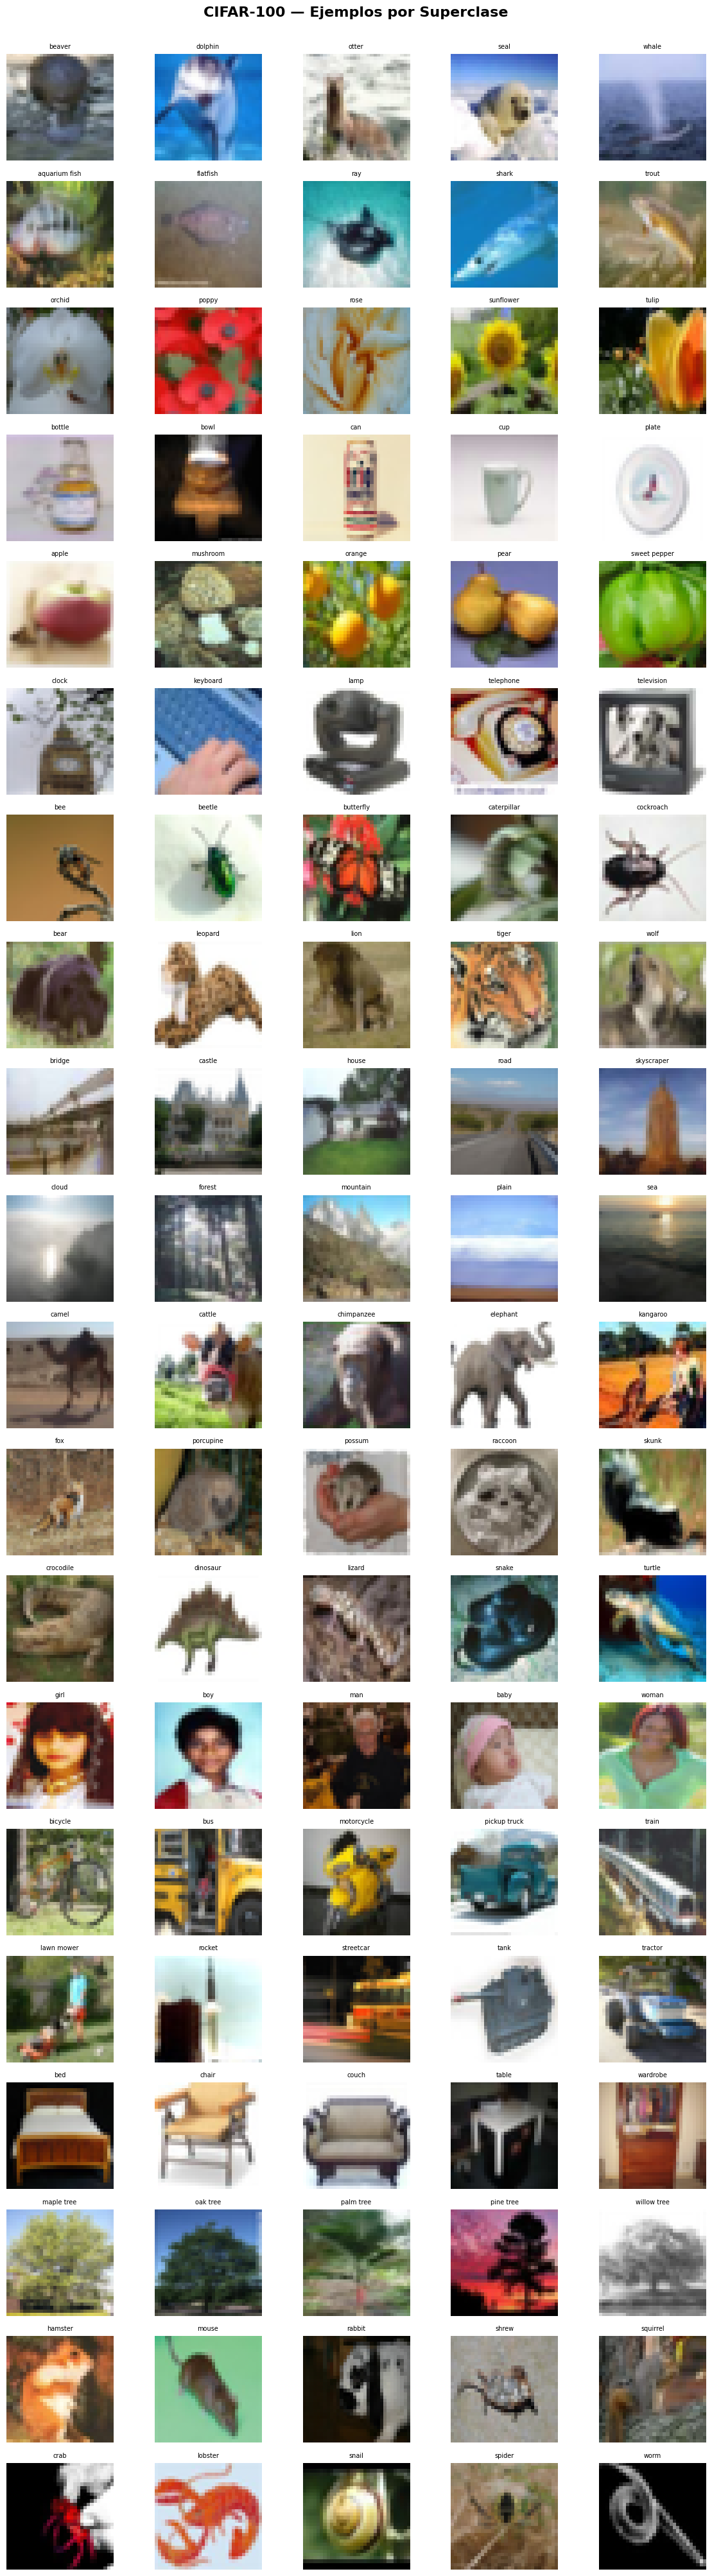

✔ Guardado: ejemplos_superclases.png

⏳ Calculando dificultad por clase...


/tmp/ipykernel_19418/2180523046.py:119: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_19418/2180523046.py:119: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_19418/2180523046.py:120: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("dificultad_clases.png", dpi=120, bbox_inches='tight')
/tmp/ipykernel_19418/2180523046.py:120: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("dificultad_clases.png", dpi=120, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) miss

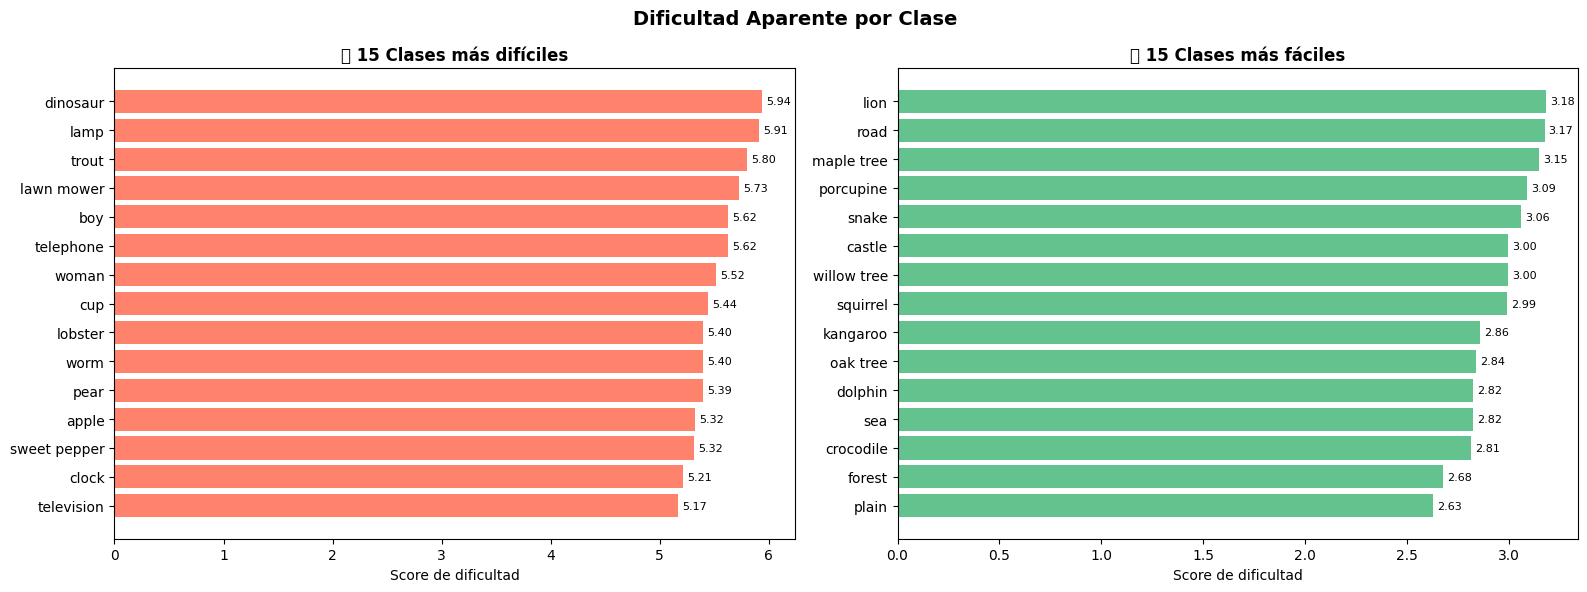

✔ Guardado: dificultad_clases.png

⏳ Calculando similitud entre clases...


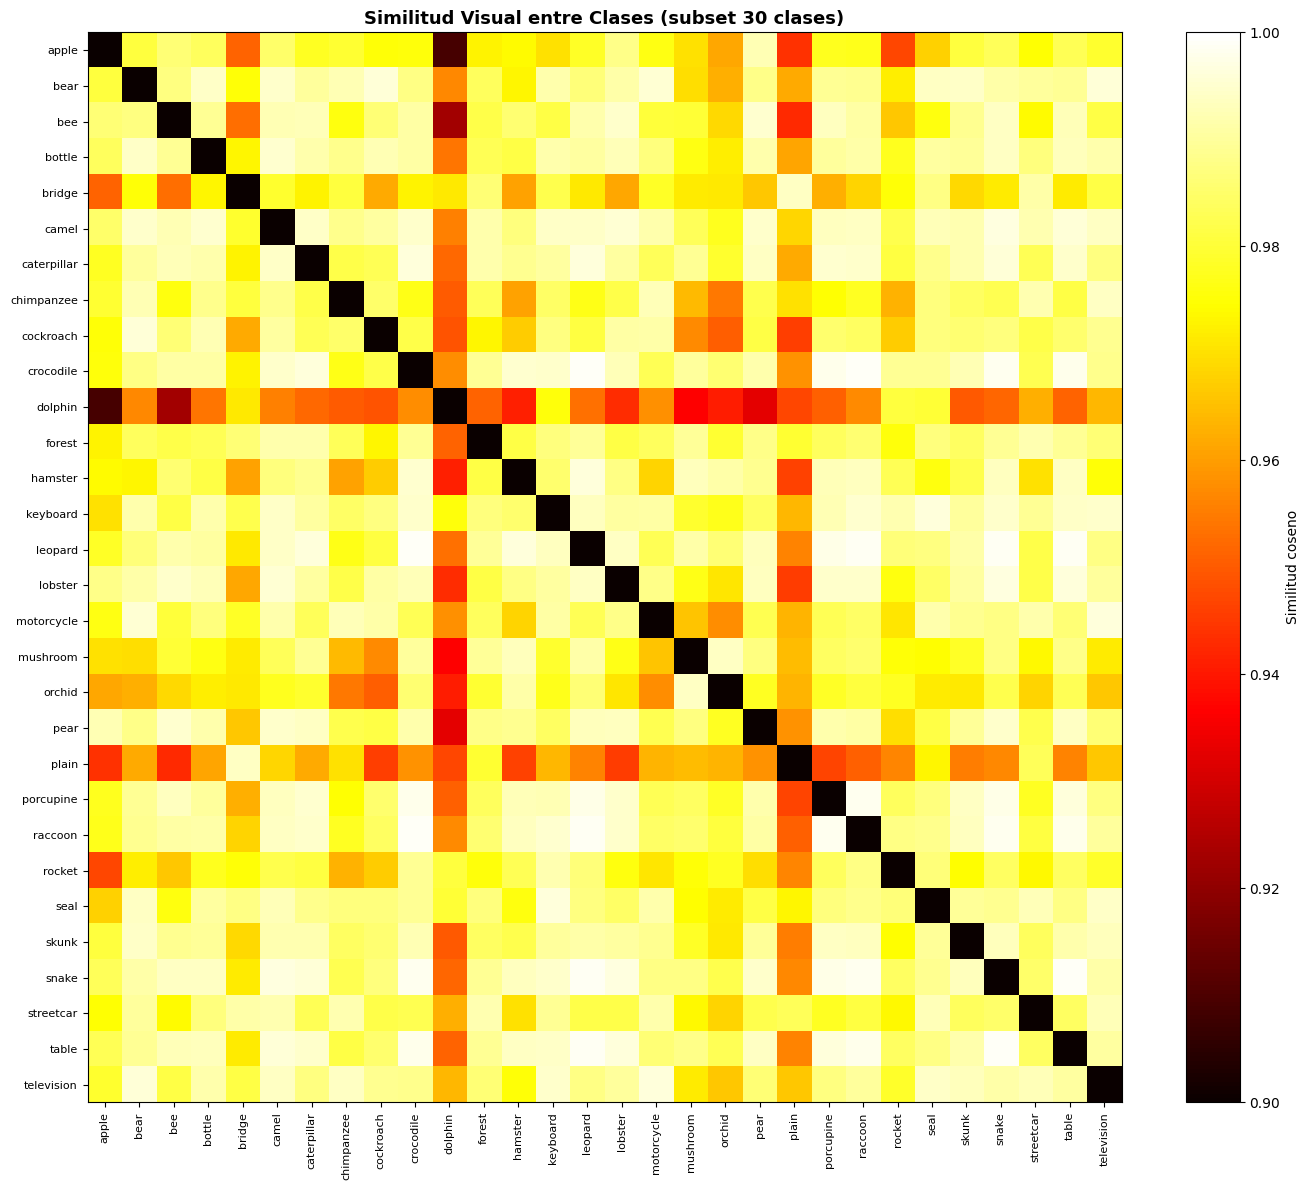

✔ Guardado: similitud_clases.png

🔁 Top 10 pares de clases más similares visualmente:
  0.9991  →  snake                 ↔  table
  0.9990  →  spider                ↔  squirrel
  0.9990  →  crocodile             ↔  leopard
  0.9989  →  lizard                ↔  raccoon
  0.9989  →  lizard                ↔  snake
  0.9989  →  fox                   ↔  tiger
  0.9989  →  crocodile             ↔  raccoon
  0.9989  →  lizard                ↔  porcupine
  0.9989  →  crocodile             ↔  lizard
  0.9988  →  leopard               ↔  lizard


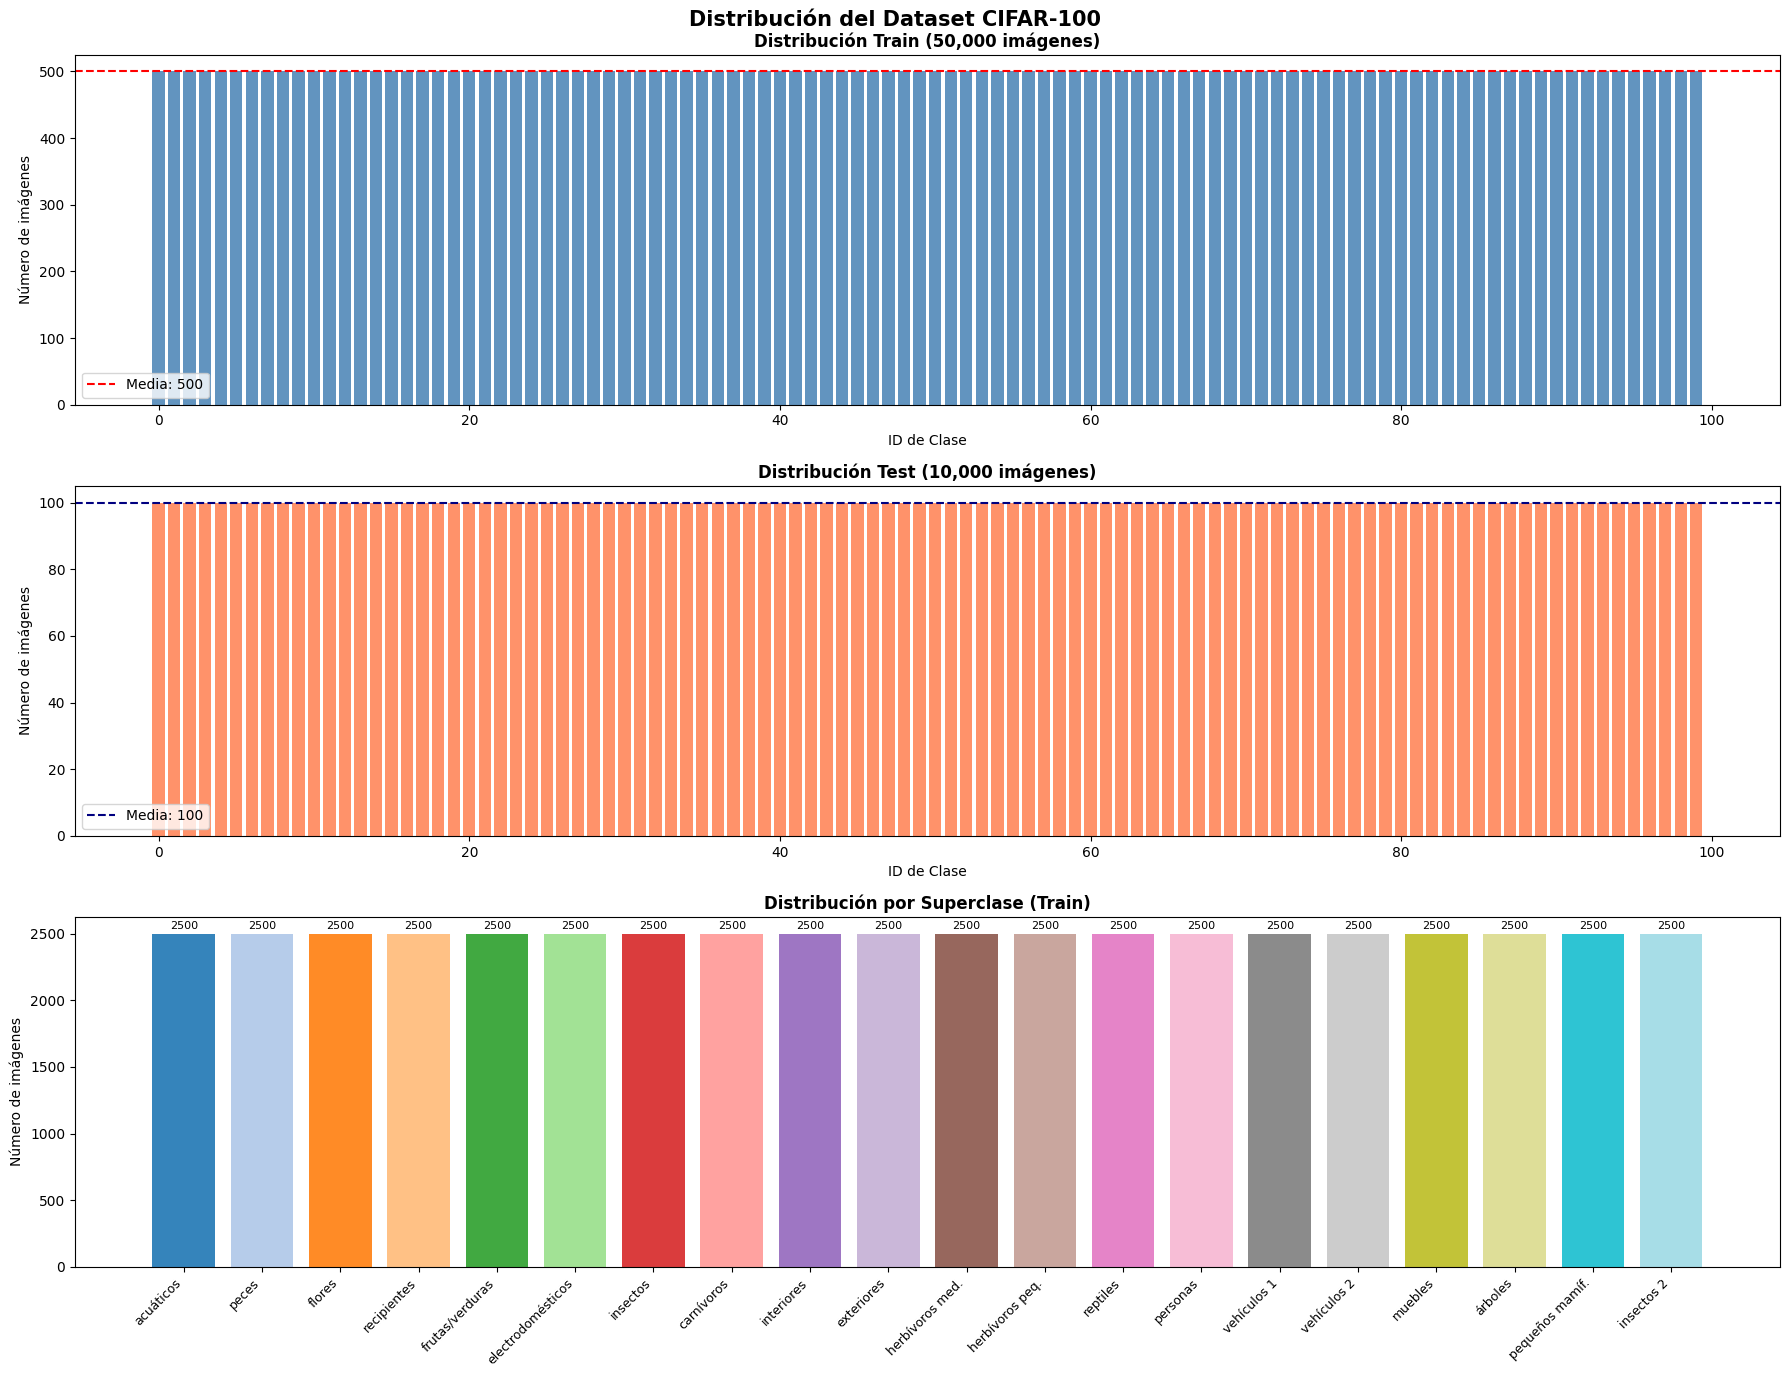

✔ Guardado: distribucion_dataset.png

  RESUMEN FINAL
  Dataset balanceado  : Sí
  Imágenes por clase  : 500 – 500 (train)
  Clase más difícil   : dinosaur  (score: 5.943)
  Clase más fácil     : plain  (score: 2.629)
  Par más similar     : snake ↔ table  (0.9991)


In [ ]:
# Reutilizamos los datasets base y helpers definidos en la primera celda.
train_data = full_train_raw
test_data = full_test_raw

# ─────────────────────────────────────────
# 1. CARGAR DATASET
# ─────────────────────────────────────────

# Superclases de CIFAR-100
superclasses = {
    "acuáticos":        ["beaver","dolphin","otter","seal","whale"],
    "peces":            ["aquarium_fish","flatfish","ray","shark","trout"],
    "flores":           ["orchid","poppy","rose","sunflower","tulip"],
    "recipientes":      ["bottle","bowl","can","cup","plate"],
    "frutas/verduras":  ["apple","mushroom","orange","pear","sweet_pepper"],
    "electrodomésticos":["clock","keyboard","lamp","telephone","television"],
    "insectos":         ["bee","beetle","butterfly","caterpillar","cockroach"],
    "carnívoros":       ["bear","leopard","lion","tiger","wolf"],
    "interiores":       ["bridge","castle","house","road","skyscraper"],
    "exteriores":       ["cloud","forest","mountain","plain","sea"],
    "herbívoros med.":  ["camel","cattle","chimpanzee","elephant","kangaroo"],
    "herbívoros peq.":  ["fox","porcupine","possum","raccoon","skunk"],
    "reptiles":         ["crocodile","dinosaur","lizard","snake","turtle"],
    "personas":         ["girl","boy","man","baby","woman"],
    "vehículos 1":      ["bicycle","bus","motorcycle","pickup_truck","train"],
    "vehículos 2":      ["lawn_mower","rocket","streetcar","tank","tractor"],
    "muebles":          ["bed","chair","couch","table","wardrobe"],
    "árboles":          ["maple_tree","oak_tree","palm_tree","pine_tree","willow_tree"],
    "pequeños mamíf.":  ["hamster","mouse","rabbit","shrew","squirrel"],
    "insectos 2":       ["crab","lobster","snail","spider","worm"],
}

# ─────────────────────────────────────────
# 2. NÚMERO DE CLASES Y SUPERCLASES
# ─────────────────────────────────────────
print("=" * 55)
print(f"  CIFAR-100 — Análisis Completo del Dataset")
print("=" * 55)
print(f"  Clases totales    : {len(classes)}")
print(f"  Superclases       : {len(superclasses)}")
print(f"  Imágenes train    : {len(train_data)}")
print(f"  Imágenes test     : {len(test_data)}")
print(f"  Resolución        : 32 x 32 px (RGB)")
print(f"  Imgs por clase    : {len(train_data) // len(classes)} (train)")
print("=" * 55)

# ─────────────────────────────────────────
# 3. EJEMPLOS VISUALES POR SUPERCLASE
# ─────────────────────────────────────────
def get_images_for_class(class_name, n=1):
    idx = classes.index(class_name)
    positions = np.where(targets == idx)[0][:n]
    return images_all[positions]

fig, axes = plt.subplots(len(superclasses), 5, figsize=(12, 40))
fig.suptitle("CIFAR-100 — Ejemplos por Superclase", fontsize=16, fontweight='bold', y=1.002)

for row, (superclass, members) in enumerate(superclasses.items()):
    for col, cls in enumerate(members):
        img = get_images_for_class(cls, n=1)[0]
        axes[row, col].imshow(img)
        axes[row, col].set_title(cls.replace("_", " "), fontsize=7)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(superclass, fontsize=8, rotation=0,
                             labelpad=70, va='center', fontweight='bold')

plt.tight_layout()
plt.savefig("ejemplos_superclases.png", dpi=120, bbox_inches='tight')
plt.show()
print("✔ Guardado: ejemplos_superclases.png")

# ─────────────────────────────────────────
# 4. DIFICULTAD APARENTE (varianza + contraste)
# ─────────────────────────────────────────
def compute_difficulty(class_name, n_samples=200):
    idx = classes.index(class_name)
    positions = np.where(targets == idx)[0][:n_samples]
    imgs = images_all[positions].astype(np.float32)

    # Varianza inter-muestra (baja varianza → imágenes muy parecidas → más fácil)
    inter_var = imgs.reshape(len(imgs), -1).var(axis=0).mean()

    # Contraste interno (bajo contraste → imagen más difícil de distinguir)
    contrast = imgs.std(axis=(1, 2, 3)).mean()

    # Score de dificultad normalizado (mayor = más difícil)
    difficulty = (inter_var / 1000) + (1 / (contrast + 1e-5)) * 5
    return round(float(difficulty), 3), round(float(inter_var), 2), round(float(contrast), 2)

print("\n⏳ Calculando dificultad por clase...")
difficulty_scores = {}
for cls in classes:
    score, ivar, cont = compute_difficulty(cls)
    difficulty_scores[cls] = {"score": score, "inter_var": ivar, "contrast": cont}

sorted_by_diff = sorted(difficulty_scores.items(), key=lambda x: x[1]['score'], reverse=True)

# Top 15 más difíciles y más fáciles
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Dificultad Aparente por Clase", fontsize=14, fontweight='bold')

top_hard  = sorted_by_diff[:15]
top_easy  = sorted_by_diff[-15:]

for ax, data, title, color in zip(
    axes,
    [top_hard, top_easy],
    ["🔴 15 Clases más difíciles", "🟢 15 Clases más fáciles"],
    ["tomato", "mediumseagreen"]
):
    names  = [d[0].replace("_", " ") for d in data]
    scores = [d[1]['score'] for d in data]
    bars = ax.barh(names, scores, color=color, alpha=0.8)
    ax.set_xlabel("Score de dificultad")
    ax.set_title(title, fontweight='bold')
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=8)
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig("dificultad_clases.png", dpi=120, bbox_inches='tight')
plt.show()
print("✔ Guardado: dificultad_clases.png")

# ─────────────────────────────────────────
# 5. CLASES SIMILARES (similitud coseno entre medias)
# ─────────────────────────────────────────
print("\n⏳ Calculando similitud entre clases...")

class_means = []
for cls in classes:
    idx = classes.index(cls)
    pos = np.where(targets == idx)[0][:300]
    mean_vec = images_all[pos].reshape(len(pos), -1).astype(np.float32).mean(axis=0)
    class_means.append(mean_vec)

class_means = np.array(class_means)
sim_matrix  = cosine_similarity(class_means)
np.fill_diagonal(sim_matrix, 0)  # Ignorar diagonal

# Heatmap de similitud (subset de 30 clases para legibilidad)
subset_idx   = list(range(0, 100, 3))[:30]
subset_names = [classes[i].replace("_", " ") for i in subset_idx]
sub_matrix   = sim_matrix[np.ix_(subset_idx, subset_idx)]

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(sub_matrix, cmap='hot', aspect='auto', vmin=0.9, vmax=1.0)
ax.set_xticks(range(len(subset_names)))
ax.set_yticks(range(len(subset_names)))
ax.set_xticklabels(subset_names, rotation=90, fontsize=8)
ax.set_yticklabels(subset_names, fontsize=8)
plt.colorbar(im, ax=ax, label="Similitud coseno")
ax.set_title("Similitud Visual entre Clases (subset 30 clases)", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig("similitud_clases.png", dpi=120, bbox_inches='tight')
plt.show()
print("✔ Guardado: similitud_clases.png")

# Top 10 pares más similares
print("\n🔁 Top 10 pares de clases más similares visualmente:")
pairs = [(sim_matrix[i, j], classes[i], classes[j])
         for i in range(100) for j in range(i+1, 100)]
pairs.sort(reverse=True)
for score, c1, c2 in pairs[:10]:
    print(f"  {score:.4f}  →  {c1:20s}  ↔  {c2}")

# ─────────────────────────────────────────
# 6. DISTRIBUCIÓN DEL DATASET
# ─────────────────────────────────────────
train_counts = Counter(train_data.targets)
test_counts  = Counter(test_data.targets)

train_vals = [train_counts[i] for i in range(100)]
test_vals  = [test_counts[i]  for i in range(100)]

fig, axes = plt.subplots(3, 1, figsize=(18, 14))
fig.suptitle("Distribución del Dataset CIFAR-100", fontsize=15, fontweight='bold')

# — Distribución train
x = np.arange(100)
axes[0].bar(x, train_vals, color='steelblue', alpha=0.85)
axes[0].axhline(np.mean(train_vals), color='red', linestyle='--', label=f'Media: {np.mean(train_vals):.0f}')
axes[0].set_title("Distribución Train (50,000 imágenes)", fontweight='bold')
axes[0].set_xlabel("ID de Clase")
axes[0].set_ylabel("Número de imágenes")
axes[0].legend()

# — Distribución test
axes[1].bar(x, test_vals, color='coral', alpha=0.85)
axes[1].axhline(np.mean(test_vals), color='navy', linestyle='--', label=f'Media: {np.mean(test_vals):.0f}')
axes[1].set_title("Distribución Test (10,000 imágenes)", fontweight='bold')
axes[1].set_xlabel("ID de Clase")
axes[1].set_ylabel("Número de imágenes")
axes[1].legend()

# — Distribución por superclase
super_counts = {}
for sup, members in superclasses.items():
    total = sum(train_counts[classes.index(m)] for m in members if m in classes)
    super_counts[sup] = total

sup_names  = list(super_counts.keys())
sup_values = list(super_counts.values())
colors_sup = plt.cm.tab20(np.linspace(0, 1, len(sup_names)))

bars = axes[2].bar(range(len(sup_names)), sup_values, color=colors_sup, alpha=0.9)
axes[2].set_xticks(range(len(sup_names)))
axes[2].set_xticklabels(sup_names, rotation=45, ha='right', fontsize=9)
axes[2].set_title("Distribución por Superclase (Train)", fontweight='bold')
axes[2].set_ylabel("Número de imágenes")
axes[2].bar_label(bars, padding=2, fontsize=8)

plt.tight_layout()
plt.savefig("distribucion_dataset.png", dpi=120, bbox_inches='tight')
plt.show()
print("✔ Guardado: distribucion_dataset.png")

# ─────────────────────────────────────────
# 7. RESUMEN FINAL
# ─────────────────────────────────────────
print("\n" + "=" * 55)
print("  RESUMEN FINAL")
print("=" * 55)
print(f"  Dataset balanceado  : {'Sí' if max(train_vals) - min(train_vals) <= 10 else 'No'}")
print(f"  Imágenes por clase  : {min(train_vals)} – {max(train_vals)} (train)")
print(f"  Clase más difícil   : {sorted_by_diff[0][0]}  (score: {sorted_by_diff[0][1]['score']})")
print(f"  Clase más fácil     : {sorted_by_diff[-1][0]}  (score: {sorted_by_diff[-1][1]['score']})")
print(f"  Par más similar     : {pairs[0][1]} ↔ {pairs[0][2]}  ({pairs[0][0]:.4f})")
print("=" * 55)

# 2- Preprocesado

Este preprocesado tiene dos objetivos principales: preparar bien los datos para entrenar y mejorar la capacidad de generalización del modelo. En computer vision esto es importante porque las imágenes son pequeñas y cada clase tiene pocas muestras.

Las decisiones principales son:
- normalizar las imágenes para que el entrenamiento sea más estable;
- separar train, validation y test para evaluar correctamente;
- aplicar augmentation solo en train para aumentar variedad sin alterar validation ni test;
- revisar visualmente las imágenes para comprobar que el pipeline tiene sentido.

Esta parte deja una base limpia para comparar modelos de forma justa.

Media CIFAR-100: (0.5071, 0.4867, 0.4408)
Std   CIFAR-100: (0.2675, 0.2565, 0.2761)
Train transform : Flip | RandomCrop | ColorJitter | Normalize
Eval transform  : ToTensor | Normalize
  SEPARACIÓN DEL DATASET
  Train      : 40,000 imágenes  (80% de train)
  Validation : 10,000 imágenes  (20% de train)
  Test       : 10,000 imágenes  (split oficial CIFAR-100)
  TOTAL      : 60,000 imágenes
  Normalización  → μ=(0.5071, 0.4867, 0.4408)  σ=(0.2675, 0.2565, 0.2761)
  Augmentations  → Flip | RandomCrop | ColorJitter (solo train)


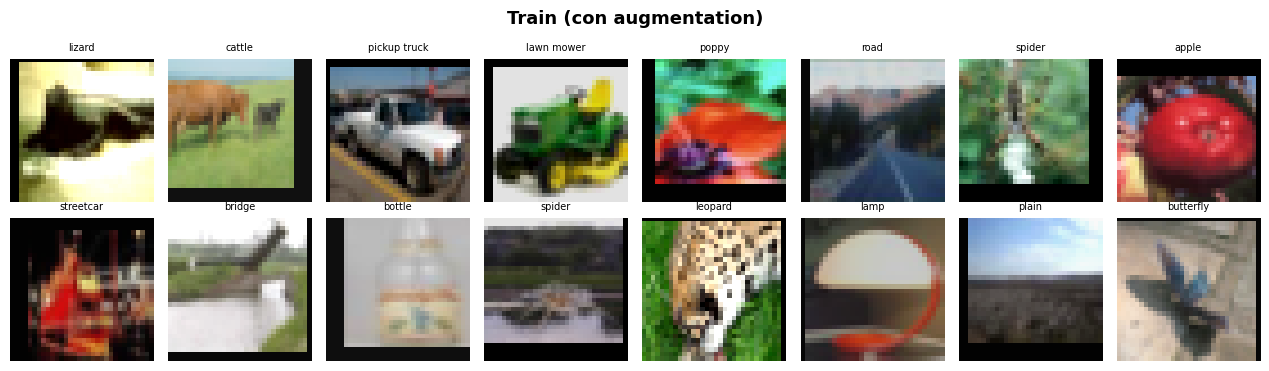

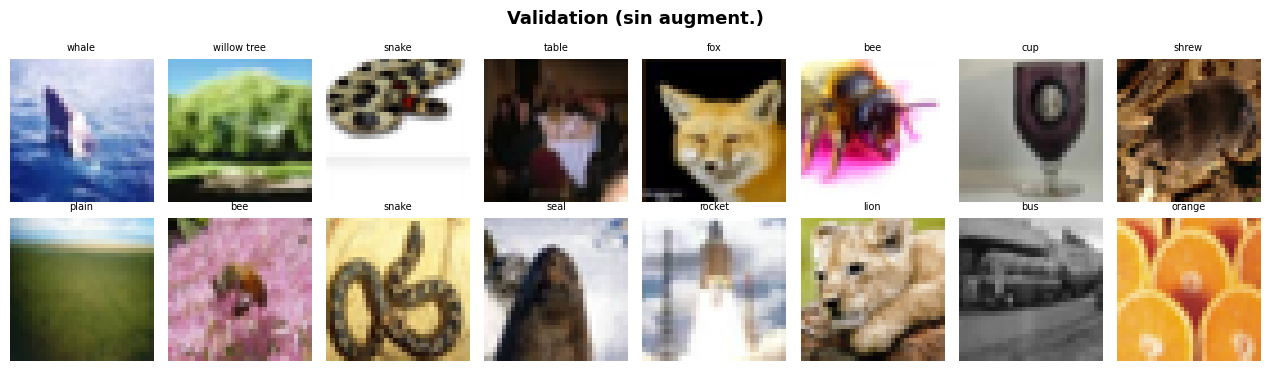

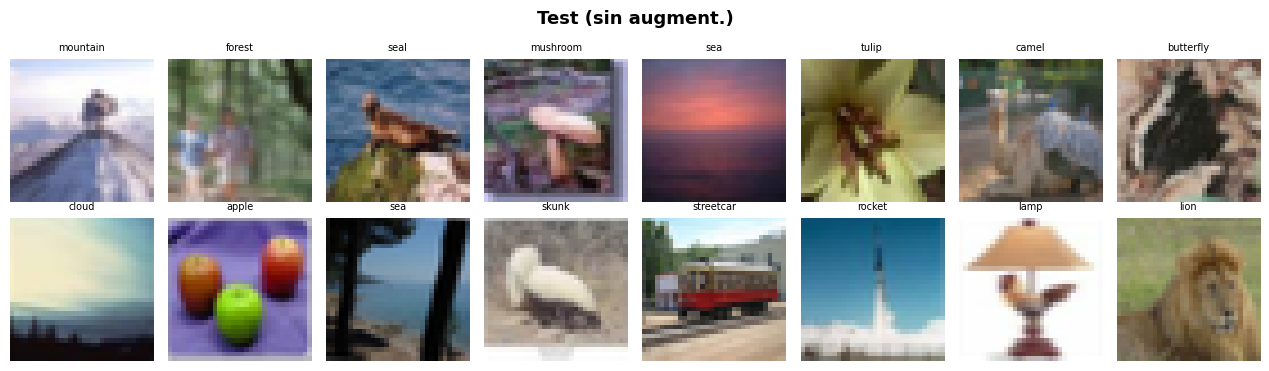

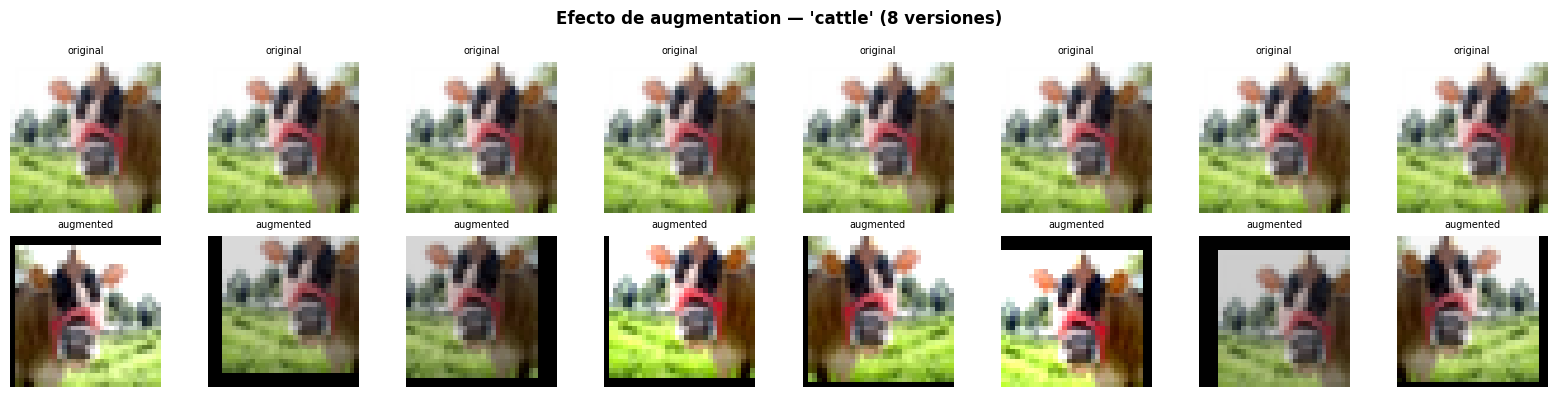

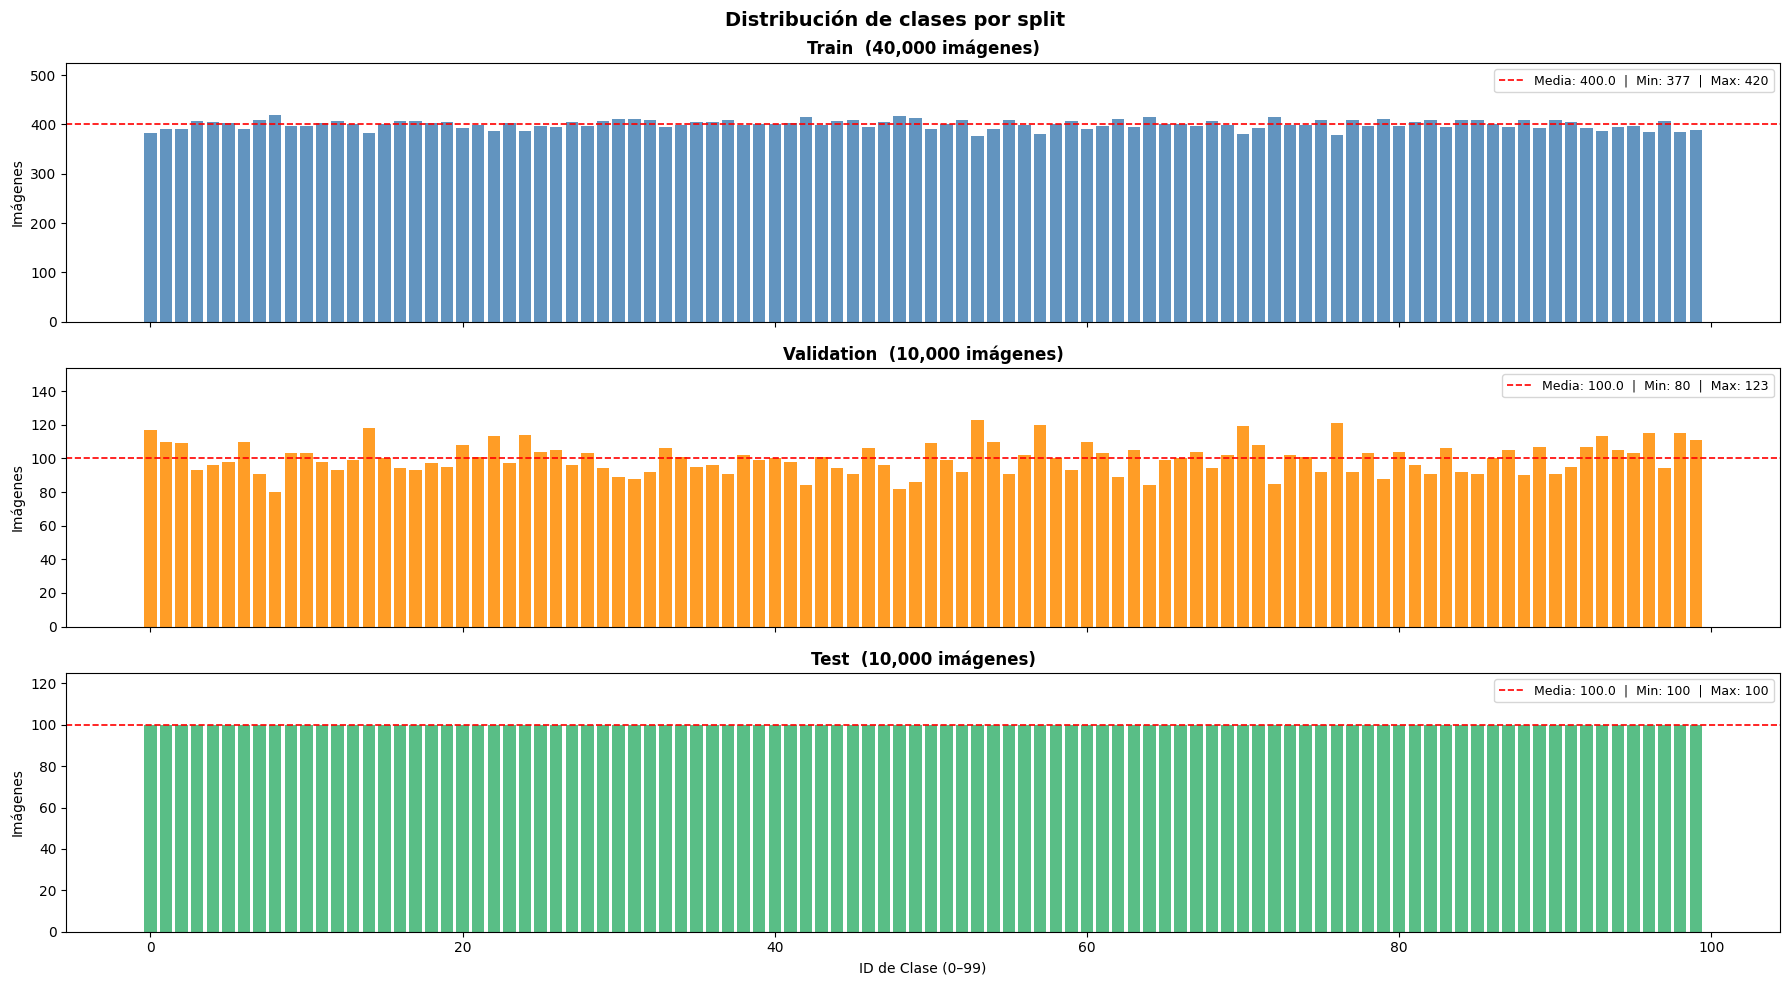


⏳ Calculando estadísticas RGB del split train...


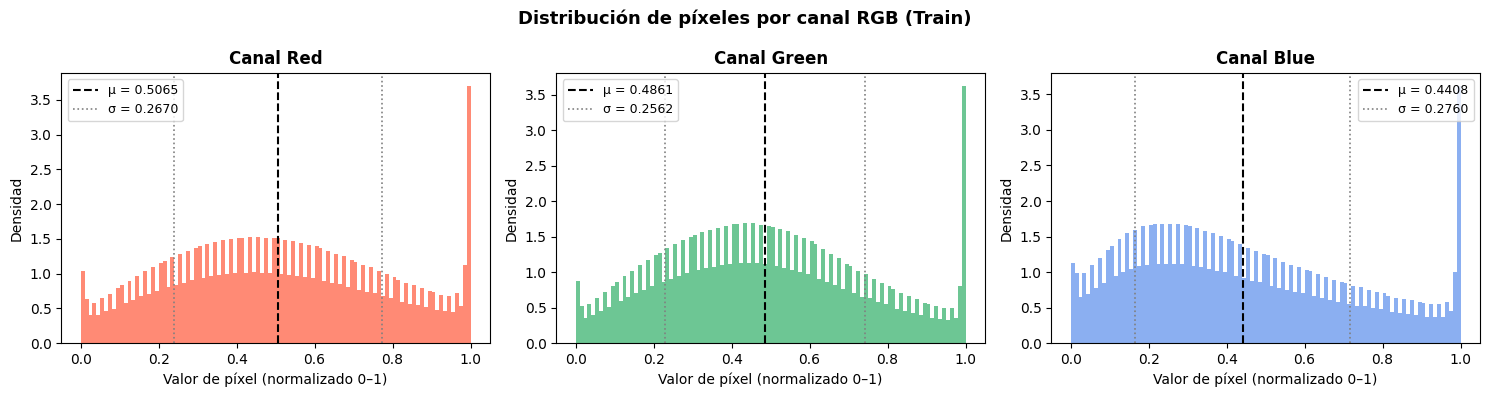

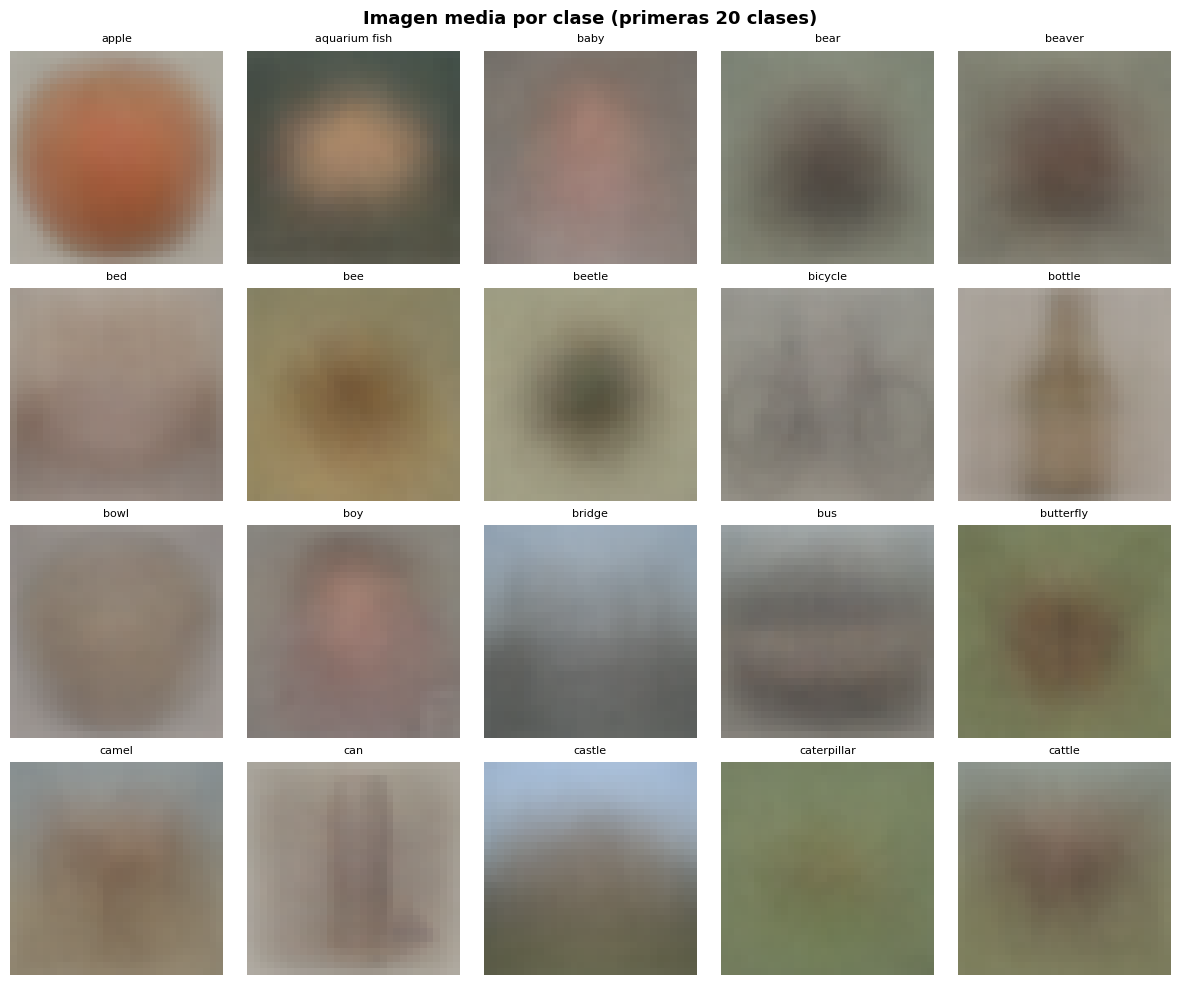


  ARCHIVOS GENERADOS
  ✔ muestras_train.png                  Muestras del split train
  ✔ muestras_validation.png             Muestras del split validation
  ✔ muestras_test.png                   Muestras del split test
  ✔ augmentation_efecto.png             Efecto de las augmentations
  ✔ distribucion_splits.png             Distribución de clases por split
  ✔ distribucion_rgb.png                Histograma RGB del train
  ✔ imagen_media_clases.png             Imagen media por clase


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║        CIFAR-100 — Preprocesamiento y Análisis Visual        ║
# ╚══════════════════════════════════════════════════════════════╝

# ─────────────────────────────────────────────────────────────────
# 1. ESTADÍSTICAS REALES DEL DATASET (para normalización correcta)
# ─────────────────────────────────────────────────────────────────
print(f"Media CIFAR-100: {CIFAR100_MEAN}")
print(f"Std   CIFAR-100: {CIFAR100_STD}")

# ─────────────────────────────────────────────────────────────────
# 2. TRANSFORMACIONES
# ─────────────────────────────────────────────────────────────────
print("Train transform : Flip | RandomCrop | ColorJitter | Normalize")
print("Eval transform  : ToTensor | Normalize")

# ─────────────────────────────────────────────────────────────────
# 3. CARGA Y SEPARACIÓN TRAIN / VAL / TEST
#    CIFAR-100 ya trae test oficial → solo dividimos train en train+val
# ─────────────────────────────────────────────────────────────────
n_total = len(full_train_raw)
n_val = int(n_total * VAL_RATIO)
n_train = n_total - n_val

generator = torch.Generator().manual_seed(SEED)
train_idx, val_idx = random_split(range(n_total), [n_train, n_val], generator=generator)

# Reutilizamos el dataset raw para visualización y creamos vistas con transforms específicas.
full_train_aug = datasets.CIFAR100(root='./data', train=True, download=False, transform=transform_train)
full_train_eval = datasets.CIFAR100(root='./data', train=True, download=False, transform=transform_eval)
test_dataset = datasets.CIFAR100(root='./data', train=False, download=False, transform=transform_eval)

train_dataset = Subset(full_train_aug, train_idx.indices)
val_dataset = Subset(full_train_eval, val_idx.indices)

# DataLoaders finales del pipeline de entrenamiento
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print("=" * 52)
print("  SEPARACIÓN DEL DATASET")
print("=" * 52)
print(f"  Train      : {len(train_dataset):>6,} imágenes  ({100*(1-VAL_RATIO):.0f}% de train)")
print(f"  Validation : {len(val_dataset):>6,} imágenes  ({100*VAL_RATIO:.0f}% de train)")
print(f"  Test       : {len(test_dataset):>6,} imágenes  (split oficial CIFAR-100)")
print(f"  TOTAL      : {len(train_dataset)+len(val_dataset)+len(test_dataset):>6,} imágenes")
print("=" * 52)
print(f"  Normalización  → μ={CIFAR100_MEAN}  σ={CIFAR100_STD}")
print("  Augmentations  → Flip | RandomCrop | ColorJitter (solo train)")
print("=" * 52)

# ─────────────────────────────────────────────────────────────────
# 4. HELPER: visualización de muestras
# ─────────────────────────────────────────────────────────────────
def show_samples(loader, title, filename, n=16):
    images, labels = next(iter(loader))
    n = min(n, len(images))
    cols = 8
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.6, rows * 1.9))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    for i, ax in enumerate(np.atleast_1d(axes).flat):
        if i >= n:
            ax.axis('off')
            continue
        ax.imshow(tensor_to_numpy(images[i], normalized=True))
        ax.set_title(classes[labels[i]].replace("_", " "), fontsize=7)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(filename, dpi=120, bbox_inches='tight')
    plt.show()

# ─────────────────────────────────────────────────────────────────
# 5. VISUALIZACIÓN DE MUESTRAS (train / val / test)
# ─────────────────────────────────────────────────────────────────
show_samples(train_loader, "Train (con augmentation)", "muestras_train.png", n=16)
show_samples(val_loader, "Validation (sin augment.)", "muestras_validation.png", n=16)
show_samples(test_loader, "Test (sin augment.)", "muestras_test.png", n=16)

# ─────────────────────────────────────────────────────────────────
# 6. EFECTO DE LAS AUGMENTATIONS (misma imagen 8 veces)
# ─────────────────────────────────────────────────────────────────
raw_img, label = full_train_raw[0]

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle(f"Efecto de augmentation — '{classes[label]}' (8 versiones)", fontsize=12, fontweight='bold')

for ax in axes[0]:
    ax.imshow(tensor_to_numpy(raw_img))
    ax.axis('off')
    ax.set_title("original", fontsize=7)

aug_only = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
])
for ax in axes[1]:
    aug_img = aug_only(raw_img)
    ax.imshow(tensor_to_numpy(aug_img))
    ax.axis('off')
    ax.set_title("augmented", fontsize=7)

plt.tight_layout()
plt.savefig("augmentation_efecto.png", dpi=120, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────
# 7. DISTRIBUCIÓN DE CLASES EN CADA SPLIT
# ─────────────────────────────────────────────────────────────────
train_counts = get_label_counts(train_dataset)
val_counts = get_label_counts(val_dataset)
test_counts = get_label_counts(test_dataset)

fig, axes = plt.subplots(3, 1, figsize=(18, 10), sharex=True)
fig.suptitle("Distribución de clases por split", fontsize=14, fontweight='bold')

colors = ['steelblue', 'darkorange', 'mediumseagreen']
splits = [("Train", train_counts, colors[0]),
          ("Validation", val_counts, colors[1]),
          ("Test", test_counts, colors[2])]

for ax, (name, counts, color) in zip(axes, splits):
    ax.bar(range(100), counts, color=color, alpha=0.85)
    ax.axhline(counts.mean(), color='red', linestyle='--', linewidth=1.2,
               label=f'Media: {counts.mean():.1f}  |  Min: {counts.min()}  |  Max: {counts.max()}')
    ax.set_ylabel("Imágenes")
    ax.set_title(f"{name}  ({counts.sum():,} imágenes)", fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(0, counts.max() * 1.25)

axes[-1].set_xlabel("ID de Clase (0–99)")
plt.tight_layout()
plt.savefig("distribucion_splits.png", dpi=120, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────
# 8. ANÁLISIS VISUAL: MEDIA Y VARIANZA POR CANAL RGB
# ─────────────────────────────────────────────────────────────────
print("\n⏳ Calculando estadísticas RGB del split train...")

all_imgs = np.array(full_train_raw.data)[train_idx.indices].astype(np.float32) / 255.0
channel_means = all_imgs.mean(axis=(0, 1, 2))
channel_stds = all_imgs.std(axis=(0, 1, 2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Distribución de píxeles por canal RGB (Train)", fontsize=13, fontweight='bold')

channel_names = ['Red', 'Green', 'Blue']
channel_colors = ['tomato', 'mediumseagreen', 'cornflowerblue']

for i, (ax, ch, color) in enumerate(zip(axes, channel_names, channel_colors)):
    pixel_values = all_imgs[:, :, :, i].flatten()
    ax.hist(pixel_values, bins=100, color=color, alpha=0.75, density=True)
    ax.axvline(channel_means[i], color='black', linestyle='--', linewidth=1.5, label=f'μ = {channel_means[i]:.4f}')
    ax.axvline(channel_means[i] + channel_stds[i], color='gray', linestyle=':', linewidth=1.2, label=f'σ = {channel_stds[i]:.4f}')
    ax.axvline(channel_means[i] - channel_stds[i], color='gray', linestyle=':', linewidth=1.2)
    ax.set_title(f"Canal {ch}", fontweight='bold')
    ax.set_xlabel("Valor de píxel (normalizado 0–1)")
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("distribucion_rgb.png", dpi=120, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────
# 9. IMAGEN MEDIA POR CLASE (primeras 20 clases)
# ─────────────────────────────────────────────────────────────────
train_raw_arr = np.array(full_train_raw.data)
train_targets = np.array(full_train_raw.targets)

fig, axes = plt.subplots(4, 5, figsize=(12, 10))
fig.suptitle("Imagen media por clase (primeras 20 clases)", fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat):
    idx = np.where(train_targets == i)[0]
    mean_img = train_raw_arr[idx].mean(axis=0).astype(np.uint8)
    ax.imshow(mean_img)
    ax.set_title(classes[i].replace("_", " "), fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig("imagen_media_clases.png", dpi=120, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────
# 10. RESUMEN FINAL
# ─────────────────────────────────────────────────────────────────
print("\n" + "=" * 52)
print("  ARCHIVOS GENERADOS")
print("=" * 52)
outputs = [
    ("muestras_train.png", "Muestras del split train"),
    ("muestras_validation.png", "Muestras del split validation"),
    ("muestras_test.png", "Muestras del split test"),
    ("augmentation_efecto.png", "Efecto de las augmentations"),
    ("distribucion_splits.png", "Distribución de clases por split"),
    ("distribucion_rgb.png", "Histograma RGB del train"),
    ("imagen_media_clases.png", "Imagen media por clase"),
]
for fname, desc in outputs:
    print(f"  ✔ {fname:<35} {desc}")
print("=" * 52)

# Testeo de técnicas clásicas

Acá se probrán técnicas clásicas de visión por computador. La idea es comprobar si algunos cambios previos sobre la imagen pueden resaltar información útil para la clasificación.

Aquí no basta con aplicar una técnica y enseñar una imagen. También hay que explicar qué cambia, por qué podría ayudar y cómo se interpreta el resultado.

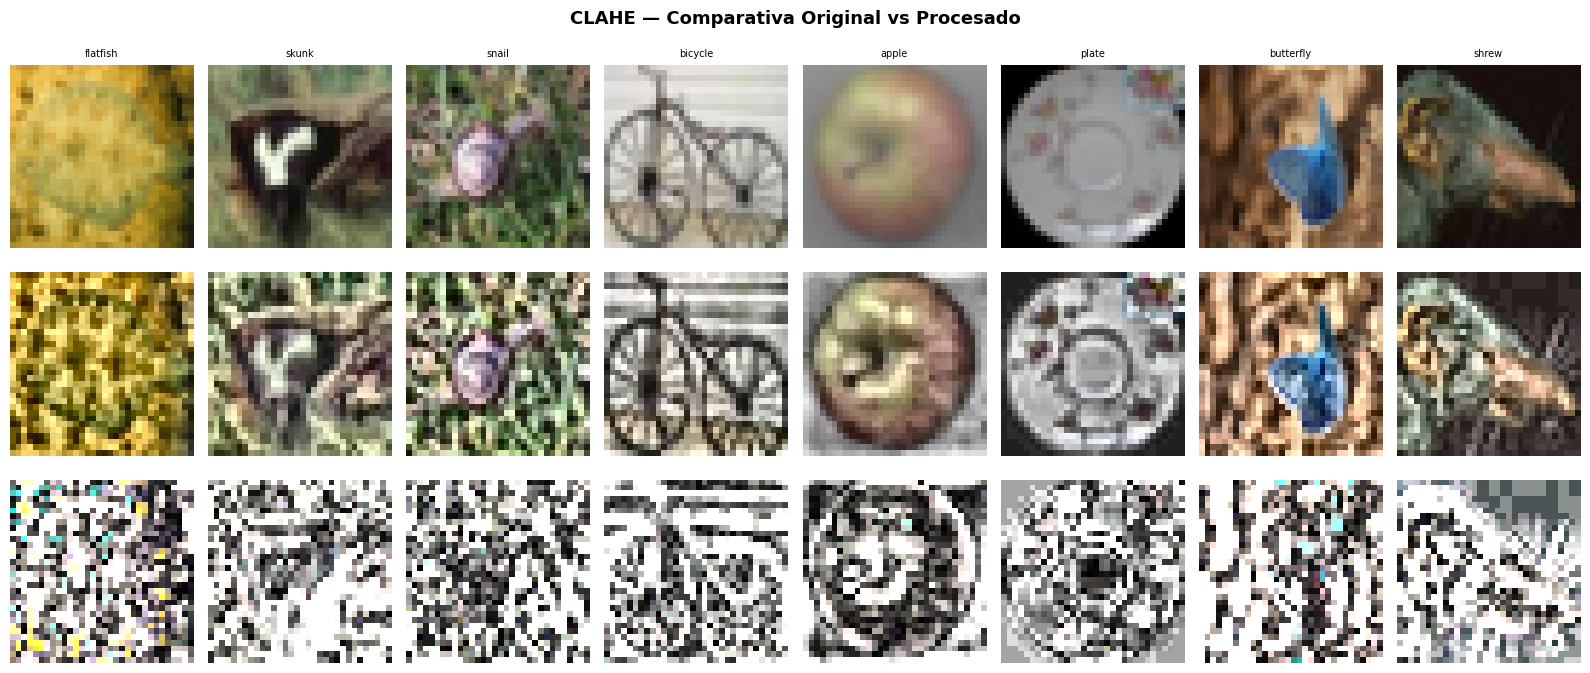

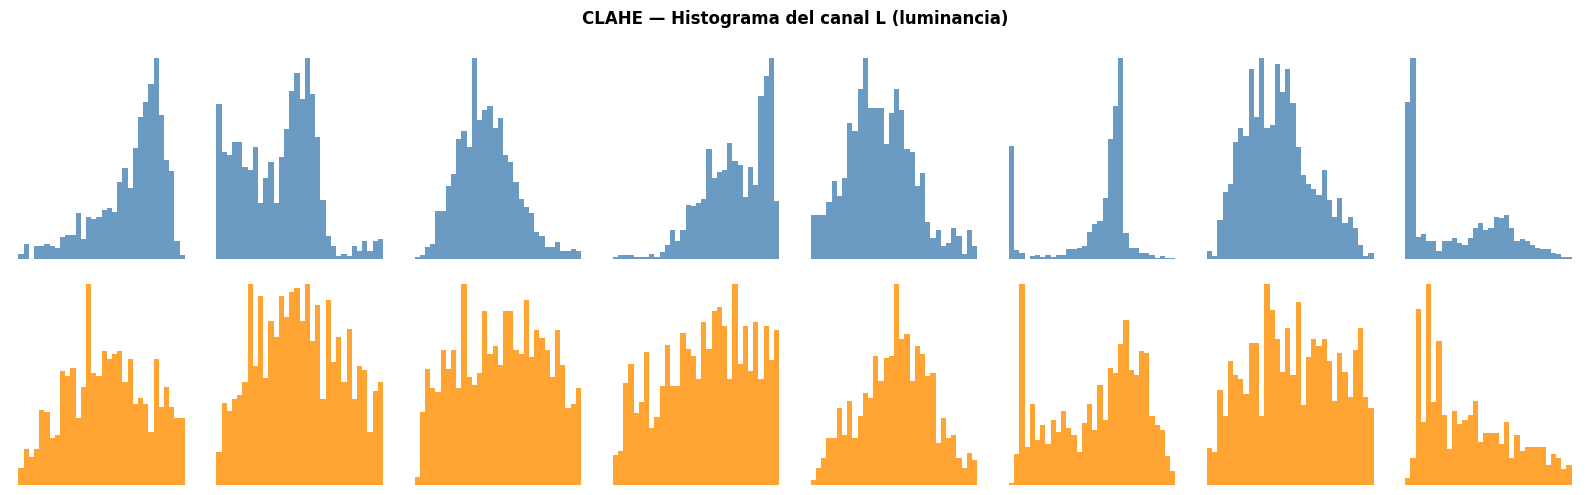

✔ CLAHE aplicado y guardado
  Clip limit : 2.0  |  Tile grid : 8×8
  Espacio    : LAB (solo canal L)
  Train CLAHE loader: 40,000 imágenes


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║                    CELDA 1 — CLAHE                           ║
# ╚══════════════════════════════════════════════════════════════╝

# ─────────────────────────────────────────────────────────────────
# CLAHE (Contrast Limited Adaptive Histogram Equalization)
#   → Opera en espacio LAB: solo mejora el canal L (luminancia)
#     sin alterar los colores originales
# ─────────────────────────────────────────────────────────────────
def apply_clahe(image_np, clip_limit=2.0, tile_grid=(8, 8)):
    lab = cv2.cvtColor(image_np, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    l_eq = clahe.apply(l)
    return cv2.cvtColor(cv2.merge([l_eq, a, b]), cv2.COLOR_LAB2RGB)

transform_clahe = build_processed_transform(lambda img: apply_clahe(img, clip_limit=2.0))
full_clahe = datasets.CIFAR100(root='./data', train=True, download=False, transform=transform_clahe)
train_clahe = Subset(full_clahe, train_idx.indices)
train_clahe_loader = DataLoader(train_clahe, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

n_show = 8
sample_idxs = train_idx.indices[:n_show]

fig, axes = plt.subplots(3, n_show, figsize=(n_show * 2, 7))
fig.suptitle("CLAHE — Comparativa Original vs Procesado", fontsize=13, fontweight='bold')

for col, idx in enumerate(sample_idxs):
    img_orig, label = full_train_raw[idx]
    orig_np = tensor_to_numpy(img_orig)
    axes[0, col].imshow(orig_np)
    axes[0, col].set_title(classes[label].replace("_", " "), fontsize=7)
    axes[0, col].axis('off')

    img_cl, _ = full_clahe[idx]
    cl_np = tensor_to_numpy(img_cl, normalized=True)
    axes[1, col].imshow(cl_np)
    axes[1, col].axis('off')

    diff = np.abs(orig_np - cl_np) * 5
    axes[2, col].imshow(diff.clip(0, 1), cmap='hot')
    axes[2, col].axis('off')

axes[0, 0].set_ylabel("Original", fontsize=9, rotation=0, labelpad=55, va='center')
axes[1, 0].set_ylabel("CLAHE", fontsize=9, rotation=0, labelpad=55, va='center')
axes[2, 0].set_ylabel("Diferencia\n(×5)", fontsize=9, rotation=0, labelpad=55, va='center')

plt.tight_layout()
plt.savefig("clahe_comparativa.png", dpi=130, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, n_show, figsize=(n_show * 2, 5))
fig.suptitle("CLAHE — Histograma del canal L (luminancia)", fontsize=12, fontweight='bold')

for col, idx in enumerate(sample_idxs):
    img_orig_np = (tensor_to_numpy(full_train_raw[idx][0]) * 255).astype(np.uint8)
    img_cl_np = (tensor_to_numpy(full_clahe[idx][0], normalized=True) * 255).astype(np.uint8)

    l_orig = cv2.cvtColor(img_orig_np, cv2.COLOR_RGB2LAB)[:, :, 0].flatten()
    l_cl = cv2.cvtColor(img_cl_np, cv2.COLOR_RGB2LAB)[:, :, 0].flatten()

    axes[0, col].hist(l_orig, bins=32, color='steelblue', alpha=0.8, density=True)
    axes[1, col].hist(l_cl, bins=32, color='darkorange', alpha=0.8, density=True)
    axes[0, col].axis('off')
    axes[1, col].axis('off')

axes[0, 0].set_ylabel("Original", fontsize=9, rotation=0, labelpad=50, va='center')
axes[1, 0].set_ylabel("CLAHE", fontsize=9, rotation=0, labelpad=50, va='center')

plt.tight_layout()
plt.savefig("clahe_histograma_L.png", dpi=130, bbox_inches='tight')
plt.show()

print("✔ CLAHE aplicado y guardado")
print("  Clip limit : 2.0  |  Tile grid : 8×8")
print("  Espacio    : LAB (solo canal L)")
print(f"  Train CLAHE loader: {len(train_clahe):,} imágenes")

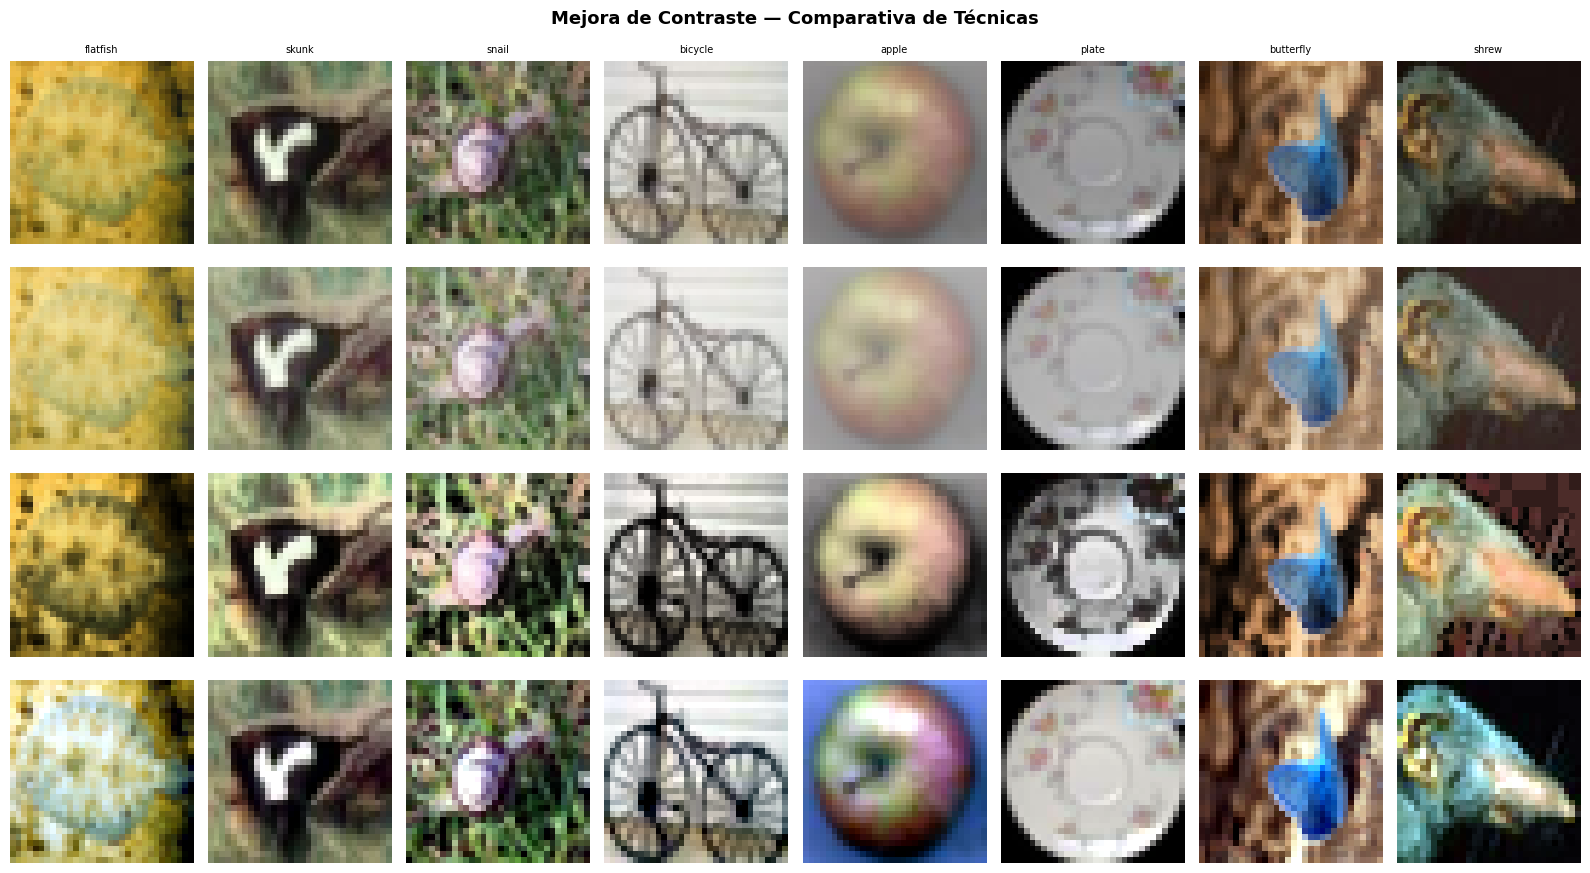

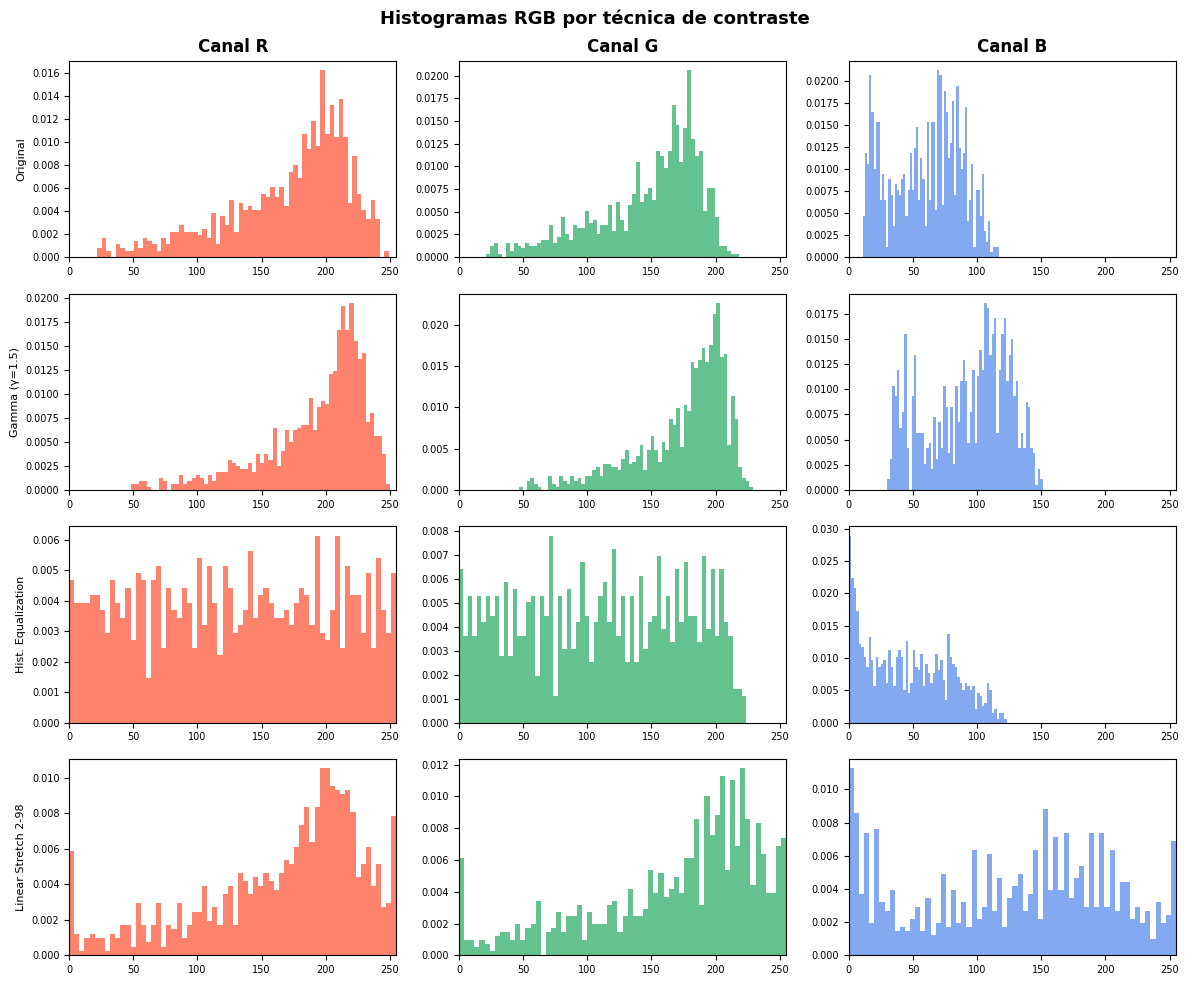

✔ Mejora de contraste aplicada y guardada
  A) Gamma Correction   γ=1.5
  B) Hist. Equalization (canal V en HSV)
  C) Linear Stretch     percentil 2–98


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║             CELDA 2 — MEJORA DE CONTRASTE                    ║
# ╚══════════════════════════════════════════════════════════════╝

# ─────────────────────────────────────────────────────────────────
# Tres técnicas de mejora de contraste
# ─────────────────────────────────────────────────────────────────
def gamma_correction(img_np, gamma=1.5):
    inv_gamma = 1.0 / gamma
    table = (np.arange(256) / 255.0) ** inv_gamma * 255
    return np.clip(table, 0, 255).astype(np.uint8)[img_np]

def hist_equalization(img_np):
    hsv = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)
    hsv[:, :, 2] = cv2.equalizeHist(hsv[:, :, 2])
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

def linear_stretch(img_np, low_pct=2, high_pct=98):
    out = img_np.astype(np.float32)
    for c in range(3):
        lo, hi = np.percentile(out[:, :, c], [low_pct, high_pct])
        out[:, :, c] = np.clip((out[:, :, c] - lo) / (hi - lo + 1e-5) * 255, 0, 255)
    return out.astype(np.uint8)

def make_contrast_transform(method='gamma', **kwargs):
    fn_map = {
        'gamma': lambda img: gamma_correction(img, **kwargs),
        'histeq': hist_equalization,
        'stretch': lambda img: linear_stretch(img, **kwargs),
    }
    return build_processed_transform(fn_map[method])

full_gamma = datasets.CIFAR100(root='./data', train=True, download=False,
                              transform=make_contrast_transform('gamma', gamma=1.5))
full_histeq = datasets.CIFAR100(root='./data', train=True, download=False,
                               transform=make_contrast_transform('histeq'))
full_stretch = datasets.CIFAR100(root='./data', train=True, download=False,
                                transform=make_contrast_transform('stretch', low_pct=2, high_pct=98))

train_gamma_loader = DataLoader(Subset(full_gamma, train_idx.indices), batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
train_histeq_loader = DataLoader(Subset(full_histeq, train_idx.indices), batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
train_stretch_loader = DataLoader(Subset(full_stretch, train_idx.indices), batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

n_show = 8
sample_idxs = train_idx.indices[:n_show]
datasets_list = [
    (full_train_raw, "Original", False),
    (full_gamma, "Gamma (γ=1.5)", True),
    (full_histeq, "Hist. Equalization", True),
    (full_stretch, "Linear Stretch 2-98", True),
]

fig, axes = plt.subplots(4, n_show, figsize=(n_show * 2, 9))
fig.suptitle("Mejora de Contraste — Comparativa de Técnicas", fontsize=13, fontweight='bold')

for row, (ds, name, normalized) in enumerate(datasets_list):
    for col, idx in enumerate(sample_idxs):
        img, label = ds[idx]
        axes[row, col].imshow(tensor_to_numpy(img, normalized=normalized))
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(classes[label].replace("_", " "), fontsize=7)
    axes[row, 0].set_ylabel(name, fontsize=8, rotation=0, labelpad=80, va='center', fontweight='bold')

plt.tight_layout()
plt.savefig("contraste_comparativa.png", dpi=130, bbox_inches='tight')
plt.show()

idx_demo = sample_idxs[0]
fig, axes = plt.subplots(4, 3, figsize=(12, 10))
fig.suptitle("Histogramas RGB por técnica de contraste", fontsize=13, fontweight='bold')

ch_colors = ['tomato', 'mediumseagreen', 'cornflowerblue']
ch_names = ['R', 'G', 'B']

for row, (ds, name, normalized) in enumerate(datasets_list):
    img, _ = ds[idx_demo]
    img_np = (tensor_to_numpy(img, normalized=normalized) * 255).astype(np.uint8)
    for c in range(3):
        axes[row, c].hist(img_np[:, :, c].flatten(), bins=64, color=ch_colors[c], alpha=0.8, density=True)
        axes[row, c].set_xlim(0, 255)
        if row == 0:
            axes[row, c].set_title(f"Canal {ch_names[c]}", fontweight='bold')
        if c == 0:
            axes[row, c].set_ylabel(name, fontsize=8)
        axes[row, c].tick_params(labelsize=7)

plt.tight_layout()
plt.savefig("contraste_histogramas.png", dpi=130, bbox_inches='tight')
plt.show()

print("✔ Mejora de contraste aplicada y guardada")
print("  A) Gamma Correction   γ=1.5")
print("  B) Hist. Equalization (canal V en HSV)")
print("  C) Linear Stretch     percentil 2–98")

## Interpretación de CLAHE y contraste

CLAHE y las técnicas de contraste buscan que algunos detalles de la imagen se vean mejor. Esto puede ayudar cuando el objeto tiene poco contraste o cuando el fondo y el objeto son parecidos.

Aun así, que una imagen se vea más clara o más intensa no significa automáticamente que el modelo vaya a clasificar mejor. Por eso, estas técnicas no deben juzgarse solo por el resultado visual, sino por su efecto posterior en validation y test.

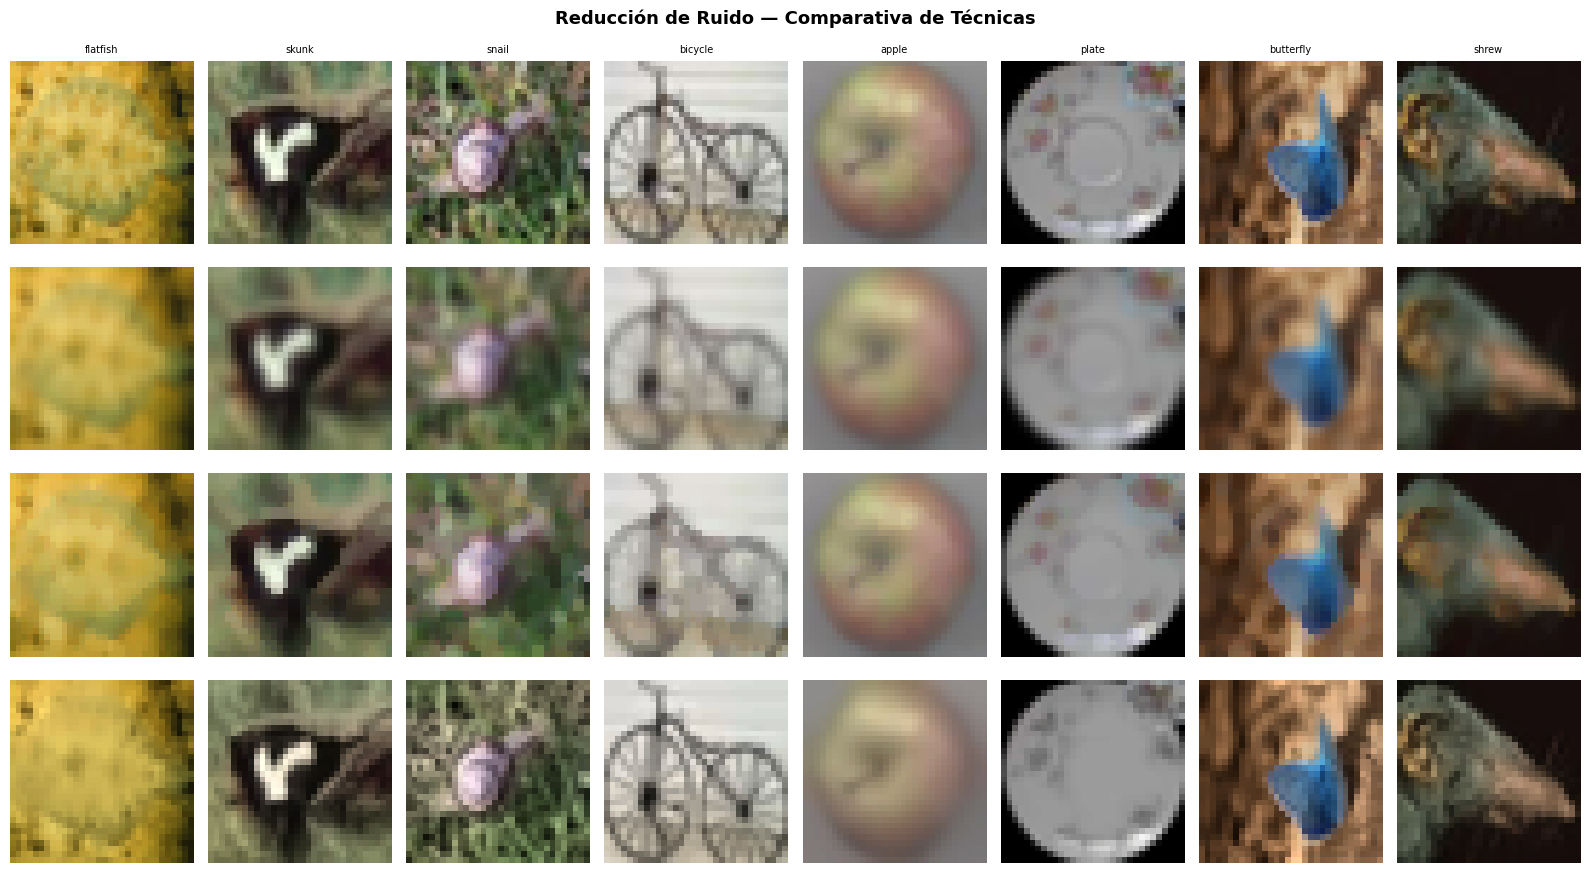

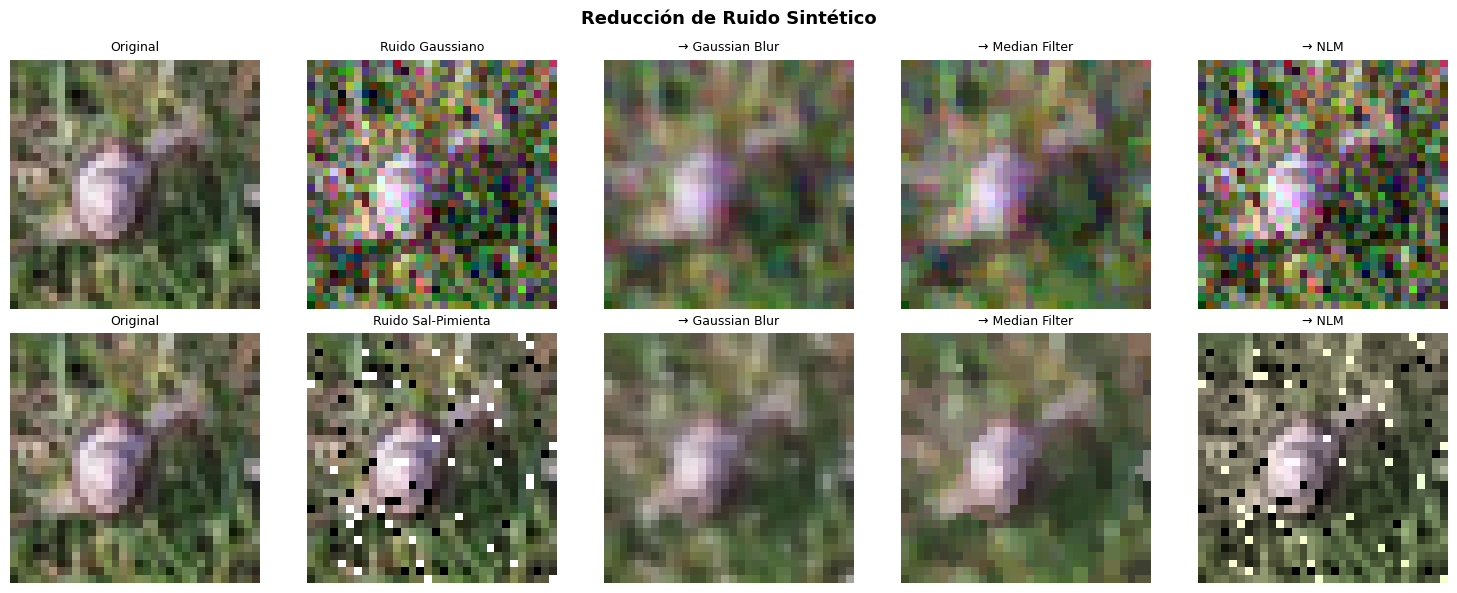

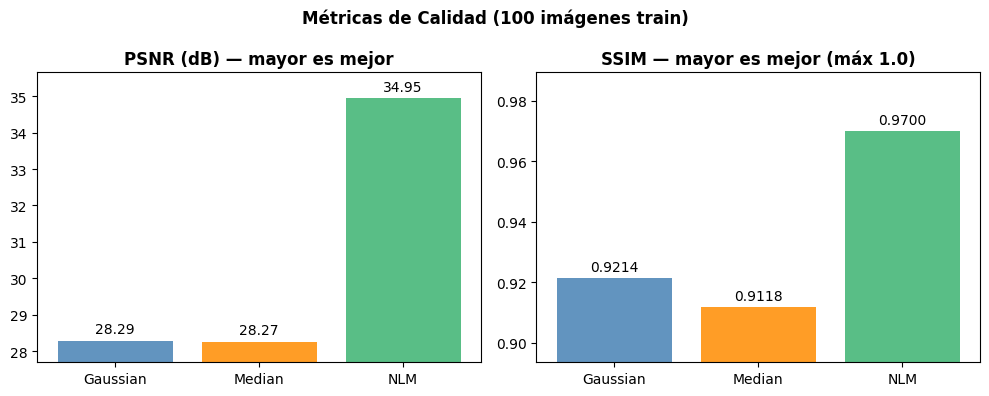


  REDUCCIÓN DE RUIDO — RESUMEN
  Método                   PSNR (dB)      SSIM
  --------------------------------------------
  Gaussian                    28.295    0.9214
  Median                      28.267    0.9118
  NLM                         34.951    0.9700
  Archivos: ruido_comparativa.png
            ruido_sintetico.png
            ruido_metricas.png


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║              CELDA 3 — REDUCCIÓN DE RUIDO                    ║
# ╚══════════════════════════════════════════════════════════════╝

# ─────────────────────────────────────────────────────────────────
# Tres técnicas de reducción de ruido
# ─────────────────────────────────────────────────────────────────

# ── A) Gaussian Blur ─────────────────────────────────────────────
def gaussian_blur(img_np, sigma=0.8):
    """Suavizado gaussiano, preserva estructura global"""
    out = np.zeros_like(img_np, dtype=np.float32)
    for c in range(3):
        out[:,:,c] = gaussian_filter(img_np[:,:,c].astype(np.float32), sigma=sigma)
    return out.clip(0, 255).astype(np.uint8)

# ── B) Median Filter ─────────────────────────────────────────────
def median_blur(img_np, size=3):
    """Elimina ruido sal-y-pimienta, preserva bordes"""
    out = np.zeros_like(img_np)
    for c in range(3):
        out[:,:,c] = median_filter(img_np[:,:,c], size=size)
    return out.astype(np.uint8)

# ── C) Non-Local Means (NLM) ─────────────────────────────────────
def nlm_denoise_rgb(img_np, h=3, template_ws=7, search_ws=21):
    bgr = cv2.fastNlMeansDenoisingColored(
        cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR), None, h, h, template_ws, search_ws)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

# ── Transform factory ─────────────────────────────────────────────
def make_denoise_transform(method='gaussian', **kwargs):
    fn_map = {
        'gaussian': lambda img: gaussian_blur(img, **kwargs),
        'median':   lambda img: median_blur(img, **kwargs),
        'nlm':      lambda img: nlm_denoise_rgb(img, **kwargs),
    }
    return build_processed_transform(fn_map[method])

# ── Datasets ──────────────────────────────────────────────────────
full_gauss   = datasets.CIFAR100(root='./data', train=True, download=False,
                                  transform=make_denoise_transform('gaussian', sigma=0.8))
full_median  = datasets.CIFAR100(root='./data', train=True, download=False,
                                  transform=make_denoise_transform('median',   size=3))
full_nlm     = datasets.CIFAR100(root='./data', train=True, download=False,
                                  transform=make_denoise_transform('nlm',      h=4))

# DataLoaders
train_gauss_loader  = DataLoader(Subset(full_gauss,  train_idx.indices), batch_size=BATCH_SIZE,
                                  shuffle=True, num_workers=NUM_WORKERS)
train_median_loader = DataLoader(Subset(full_median, train_idx.indices), batch_size=BATCH_SIZE,
                                  shuffle=True, num_workers=NUM_WORKERS)
train_nlm_loader    = DataLoader(Subset(full_nlm,    train_idx.indices), batch_size=BATCH_SIZE,
                                  shuffle=True, num_workers=NUM_WORKERS)

# ── Añadir ruido sintético para demostrar la reducción ────────────
def add_noise(img_np, noise_type='gaussian', amount=0.05):
    img_f = img_np.astype(np.float32) / 255.0
    if noise_type == 'gaussian':
        noisy = img_f + np.random.normal(0, amount, img_f.shape)
    elif noise_type == 'salt_pepper':
        noisy = img_f.copy()
        sp    = np.random.rand(*img_f.shape[:2])
        noisy[sp < amount/2]  = 0.0
        noisy[sp > 1-amount/2] = 1.0
    return (noisy.clip(0, 1) * 255).astype(np.uint8)

# ── Visualización 1: comparativa 4×8 ─────────────────────────────
n_show      = 8
sample_idxs = train_idx.indices[:n_show]

datasets_vis = [
    (full_train_raw, "Original"),
    (full_gauss, "Gaussian (σ=0.8)"),
    (full_median,"Median (3×3)"),
    (full_nlm,   "NLM (h=4)"),
]

fig, axes = plt.subplots(4, n_show, figsize=(n_show * 2, 9))
fig.suptitle("Reducción de Ruido — Comparativa de Técnicas", fontsize=13, fontweight='bold')

for row, (ds, name) in enumerate(datasets_vis):
    for col, idx in enumerate(sample_idxs):
        img, label = ds[idx]
        img_np = tensor_to_numpy(img, normalized=(ds is not full_train_raw))
        axes[row, col].imshow(img_np)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(classes[label].replace("_"," "), fontsize=7)
    axes[row, 0].set_ylabel(name, fontsize=8, rotation=0, labelpad=80, va='center', fontweight='bold')

plt.tight_layout()
plt.savefig("ruido_comparativa.png", dpi=130, bbox_inches='tight')
plt.show()

# ── Visualización 2: con ruido sintético y su reducción ───────────
idx_demo = train_idx.indices[2]
img_orig_np = (tensor_to_numpy(full_train_raw[idx_demo][0]) * 255).astype(np.uint8)

img_noisy_g  = add_noise(img_orig_np, 'gaussian',    amount=0.12)
img_noisy_sp = add_noise(img_orig_np, 'salt_pepper', amount=0.08)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Reducción de Ruido Sintético", fontsize=13, fontweight='bold')

# Fila 0: ruido gaussiano y su denoising
row0 = [
    (img_orig_np,                        "Original"),
    (img_noisy_g,                        "Ruido Gaussiano"),
    (gaussian_blur(img_noisy_g, 0.8),    "→ Gaussian Blur"),
    (median_blur(img_noisy_g, 3),        "→ Median Filter"),
    (nlm_denoise_rgb(img_noisy_g, h=4),  "→ NLM"),
]
# Fila 1: ruido sal-y-pimienta
row1 = [
    (img_orig_np,                         "Original"),
    (img_noisy_sp,                        "Ruido Sal-Pimienta"),
    (gaussian_blur(img_noisy_sp, 0.8),    "→ Gaussian Blur"),
    (median_blur(img_noisy_sp, 3),        "→ Median Filter"),
    (nlm_denoise_rgb(img_noisy_sp, h=4),  "→ NLM"),
]

for col, (img, title) in enumerate(row0):
    axes[0, col].imshow(img)
    axes[0, col].set_title(title, fontsize=9)
    axes[0, col].axis('off')
for col, (img, title) in enumerate(row1):
    axes[1, col].imshow(img)
    axes[1, col].set_title(title, fontsize=9)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel("Gaussiano", fontsize=9, rotation=0, labelpad=60, va='center')
axes[1, 0].set_ylabel("Sal-Pimienta", fontsize=9, rotation=0, labelpad=60, va='center')

plt.tight_layout()
plt.savefig("ruido_sintetico.png", dpi=130, bbox_inches='tight')
plt.show()

# ── Visualización 3: PSNR y SSIM por método ───────────────────────
methods_results = {}
for name, ds in [("Gaussian", full_gauss), ("Median", full_median), ("NLM", full_nlm)]:
    psnrs, ssims = [], []
    for idx in train_idx.indices[:100]:
        orig_np = (tensor_to_numpy(full_train_raw[idx][0]) * 255).astype(np.uint8)
        proc_np = (tensor_to_numpy(ds[idx][0], normalized=True) * 255).astype(np.uint8)
        psnrs.append(psnr(orig_np, proc_np))
        ssims.append(ssim(orig_np, proc_np, channel_axis=2, data_range=255))
    methods_results[name] = {'PSNR': np.mean(psnrs), 'SSIM': np.mean(ssims)}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Métricas de Calidad (100 imágenes train)", fontsize=12, fontweight='bold')

names   = list(methods_results.keys())
psnr_v  = [methods_results[n]['PSNR'] for n in names]
ssim_v  = [methods_results[n]['SSIM'] for n in names]
colors  = ['steelblue', 'darkorange', 'mediumseagreen']

for ax, values, metric, fmt in zip(
    axes,
    [psnr_v, ssim_v],
    ["PSNR (dB) — mayor es mejor", "SSIM — mayor es mejor (máx 1.0)"],
    [".2f", ".4f"]
):
    bars = ax.bar(names, values, color=colors, alpha=0.85)
    ax.set_title(metric, fontweight='bold')
    ax.bar_label(bars, fmt=f'%{fmt}', padding=3)
    ax.set_ylim(min(values)*0.98, max(values)*1.02)

plt.tight_layout()
plt.savefig("ruido_metricas.png", dpi=130, bbox_inches='tight')
plt.show()

# ── Resumen ───────────────────────────────────────────────────────
print("\n" + "=" * 58)
print("  REDUCCIÓN DE RUIDO — RESUMEN")
print("=" * 58)
print(f"  {'Método':<22}  {'PSNR (dB)':>10}  {'SSIM':>8}")
print("  " + "-" * 44)
for name, vals in methods_results.items():
    print(f"  {name:<22}  {vals['PSNR']:>10.3f}  {vals['SSIM']:>8.4f}")
print("=" * 58)
print("  Archivos: ruido_comparativa.png")
print("            ruido_sintetico.png")
print("            ruido_metricas.png")
print("=" * 58)

# Infraestructura común de entrenamiento y evaluación

## Interpretación de la reducción de ruido

Reducir ruido puede ayudar a limpiar la imagen, pero también puede borrar detalles importantes. En CIFAR-100 esto es delicado porque las imágenes ya son pequeñas y cualquier pérdida de detalle puede afectar a la clasificación.

Las métricas PSNR y SSIM sirven para medir cuánto se parece la imagen procesada a la original. Aun así, una técnica que conserve mejor la imagen no tiene por qué mejorar la accuracy. Por eso, la decisión final debe hacerse comparando también el comportamiento de los modelos.



Para comparar los modelos de forma justa, todos se evalúan con la misma idea general: medir rendimiento y medir generalización. No interesa solo que un modelo aprenda bien el train, sino que también funcione bien en validation y test.

Por eso, para cada modelo se calculan:
- accuracy en train, validation y test;
- curvas de entrenamiento;
- matriz de confusión;
- classification report;
- ejemplos de error;
- gap entre train y validation para detectar overfitting.

Así se puede comparar no solo qué modelo acierta más, sino también cuál generaliza mejor.

In [ ]:
import copy
import time
from pathlib import Path

import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix
from torchvision import models

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PIN_MEMORY = DEVICE.type == 'cuda'
ARTIFACT_DIR = Path('artifacts')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_RESULTS = {}

if DEVICE.type == 'cuda':
    torch.backends.cudnn.benchmark = True

def seed_everything(seed=SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def epochs_for(target_epochs):
    scale = 1.0 if DEVICE.type == 'cuda' else 0.5
    return max(3, int(round(target_epochs * scale)))

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def tensor_to_numpy_with_stats(image, mean=None, std=None):
    image = image.detach().cpu()
    if mean is not None and std is not None:
        mean_t = torch.tensor(mean, dtype=image.dtype).view(3, 1, 1)
        std_t = torch.tensor(std, dtype=image.dtype).view(3, 1, 1)
        image = (image * std_t + mean_t).clamp(0, 1)
    return image.permute(1, 2, 0).numpy()

def build_split_loaders(train_transform, eval_transform=None, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS):
    eval_transform = eval_transform or train_transform
    train_ds = Subset(datasets.CIFAR100(root='./data', train=True, download=False, transform=train_transform), train_idx.indices)
    val_ds = Subset(datasets.CIFAR100(root='./data', train=True, download=False, transform=eval_transform), val_idx.indices)
    test_ds = datasets.CIFAR100(root='./data', train=False, download=False, transform=eval_transform)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=PIN_MEMORY)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=PIN_MEMORY)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=PIN_MEMORY)
    return train_loader, val_loader, test_loader

def train_one_epoch(model, loader, criterion, optimizer, device=DEVICE):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        correct += (outputs.argmax(dim=1) == targets).sum().item()
        total += targets.size(0)

    return running_loss / total, correct / total

@torch.no_grad()
def evaluate_loader(model, loader, criterion=None, device=DEVICE, collect_arrays=False):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    y_true, y_pred, y_prob = [], [], []

    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        outputs = model(inputs)

        if criterion is not None:
            running_loss += criterion(outputs, targets).item() * inputs.size(0)

        probs = torch.softmax(outputs, dim=1)
        preds = probs.argmax(dim=1)
        correct += (preds == targets).sum().item()
        total += targets.size(0)

        if collect_arrays:
            y_true.append(targets.cpu().numpy())
            y_pred.append(preds.cpu().numpy())
            y_prob.append(probs.cpu().numpy())

    result = {
        'loss': running_loss / total if criterion is not None else None,
        'accuracy': correct / total,
    }

    if collect_arrays:
        result['y_true'] = np.concatenate(y_true)
        result['y_pred'] = np.concatenate(y_pred)
        result['y_prob'] = np.concatenate(y_prob)

    return result

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, scheduler=None, early_stopping=5, device=DEVICE):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_state = copy.deepcopy(model.state_dict())
    best_val_acc = -1.0
    patience = 0

    for epoch in range(1, epochs + 1):
        start = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device=device)
        val_metrics = evaluate_loader(model, val_loader, criterion=criterion, device=device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['loss'])
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_metrics['accuracy'])

        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_metrics['loss'])
            else:
                scheduler.step()

        if val_metrics['accuracy'] > best_val_acc:
            best_val_acc = val_metrics['accuracy']
            best_state = copy.deepcopy(model.state_dict())
            patience = 0
        else:
            patience += 1

        elapsed = time.time() - start
        print(f"Epoch {epoch:02d}/{epochs:02d} | train_loss={train_loss:.4f} | val_loss={val_metrics['loss']:.4f} | train_acc={train_acc:.4f} | val_acc={val_metrics['accuracy']:.4f} | {elapsed:.1f}s")

        if patience >= early_stopping:
            print(f"Early stopping activado en la época {epoch}.")
            break

    model.load_state_dict(best_state)
    return history

def extend_history(base_history, new_history):
    if not base_history:
        return {k: list(v) for k, v in new_history.items()}
    for key in base_history:
        base_history[key].extend(new_history[key])
    return base_history

def plot_training_curves(history, title):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    axes[0].plot(epochs, history['train_loss'], label='train')
    axes[0].plot(epochs, history['val_loss'], label='validation')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(epochs, history['train_acc'], label='train')
    axes[1].plot(epochs, history['val_acc'], label='validation')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix_full(y_true, y_pred, title, class_names=classes):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm, cmap='magma')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Etiqueta real')
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()
    return cm

def top_confusions_from_cm(cm, class_names=classes, top_k=10):
    pairs = []
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if i != j and cm[i, j] > 0:
                pairs.append((cm[i, j], class_names[i], class_names[j]))
    pairs.sort(reverse=True)
    return pairs[:top_k]

def show_error_examples(loader, y_true, y_pred, mean, std, title, max_items=12):
    wrong_idx = np.where(y_true != y_pred)[0][:max_items]
    if len(wrong_idx) == 0:
        print('No hay errores que mostrar en este split.')
        return

    cols = 4
    rows = int(np.ceil(len(wrong_idx) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.2, rows * 3.0))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    for plot_idx, ax in enumerate(np.atleast_1d(axes).flat):
        if plot_idx >= len(wrong_idx):
            ax.axis('off')
            continue

        ds_idx = int(wrong_idx[plot_idx])
        image, _ = loader.dataset[ds_idx]
        ax.imshow(tensor_to_numpy_with_stats(image, mean=mean, std=std))
        ax.set_title(f"real: {classes[y_true[ds_idx]]}\npred: {classes[y_pred[ds_idx]]}", fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

def slugify(name):
    return name.lower().replace(' + ', '_').replace(' ', '_').replace('(', '').replace(')', '').replace('-', '_')

def finalize_experiment(name, model, history, train_loader, val_loader, test_loader, criterion, inference_transform, mean, std, notes=''):
    train_metrics = evaluate_loader(model, train_loader, criterion=criterion, device=DEVICE)
    val_metrics = evaluate_loader(model, val_loader, criterion=criterion, device=DEVICE)
    test_metrics = evaluate_loader(model, test_loader, criterion=criterion, device=DEVICE, collect_arrays=True)

    gap = train_metrics['accuracy'] - val_metrics['accuracy']
    report_text = classification_report(test_metrics['y_true'], test_metrics['y_pred'], target_names=classes, zero_division=0)
    cm = plot_confusion_matrix_full(test_metrics['y_true'], test_metrics['y_pred'], f'{name} — Matriz de confusión')
    top_confusions = top_confusions_from_cm(cm, top_k=10)

    plot_training_curves(history, f'{name} — Curvas de entrenamiento')
    print(report_text)
    print('Top confusiones:')
    for count, c_true, c_pred in top_confusions:
        print(f'  {count:>4d}  {c_true:20s} -> {c_pred}')

    show_error_examples(test_loader, test_metrics['y_true'], test_metrics['y_pred'], mean=mean, std=std, title=f'{name} — Ejemplos de error')

    result = {
        'name': name,
        'model': model,
        'train_acc': train_metrics['accuracy'],
        'val_acc': val_metrics['accuracy'],
        'test_acc': test_metrics['accuracy'],
        'gap': gap,
        'parameters': count_parameters(model),
        'history': history,
        'notes': notes,
        'report_text': report_text,
        'top_confusions': top_confusions,
        'inference_transform': inference_transform,
        'mean': mean,
        'std': std,
    }

    torch.save({'state_dict': model.state_dict(), 'class_names': classes, 'result': {k: v for k, v in result.items() if k not in {'model', 'history', 'inference_transform'}}}, ARTIFACT_DIR / f"{slugify(name)}.pt")
    MODEL_RESULTS[name] = result

    print('=' * 68)
    print(name)
    print('=' * 68)
    print(f"Parámetros entrenables : {result['parameters']:,}")
    print(f"Train accuracy         : {result['train_acc']:.4f}")
    print(f"Validation accuracy    : {result['val_acc']:.4f}")
    print(f"Test accuracy          : {result['test_acc']:.4f}")
    print(f"Gap train-val          : {result['gap']:.4f}")
    print(f"Comentarios            : {notes}")
    print('=' * 68)
    return result

seed_everything()
print(f'Usando dispositivo: {DEVICE}')
print(f'Las épocas se escalan automáticamente en CPU: epochs_for(10) -> {epochs_for(10)}')

Usando dispositivo: cuda
Las épocas se escalan automáticamente en CPU: epochs_for(10) -> 10


# Modelo 1 - CNN Base

## Objetivo del Modelo 1

Este modelo sirve como punto de partida. Es una CNN simple, sin mejoras avanzadas, y su función es dar una referencia clara del rendimiento básico sobre CIFAR-100.



Epoch 01/12 | train_loss=3.5591 | val_loss=3.0021 | train_acc=0.1669 | val_acc=0.2594 | 14.4s
Epoch 02/12 | train_loss=2.7273 | val_loss=2.6732 | train_acc=0.3186 | val_acc=0.3227 | 15.1s
Epoch 03/12 | train_loss=2.3347 | val_loss=2.5313 | train_acc=0.3959 | val_acc=0.3565 | 13.3s
Epoch 04/12 | train_loss=2.0520 | val_loss=2.5634 | train_acc=0.4564 | val_acc=0.3676 | 13.3s
Epoch 05/12 | train_loss=1.7961 | val_loss=2.5196 | train_acc=0.5169 | val_acc=0.3811 | 13.3s
Epoch 06/12 | train_loss=1.5539 | val_loss=2.5965 | train_acc=0.5723 | val_acc=0.3770 | 13.5s
Epoch 07/12 | train_loss=1.3277 | val_loss=2.7452 | train_acc=0.6285 | val_acc=0.3791 | 13.4s
Epoch 08/12 | train_loss=1.1071 | val_loss=2.9760 | train_acc=0.6850 | val_acc=0.3623 | 21.8s
Epoch 09/12 | train_loss=0.7162 | val_loss=3.2616 | train_acc=0.7990 | val_acc=0.3697 | 13.8s
Early stopping activado en la época 9.


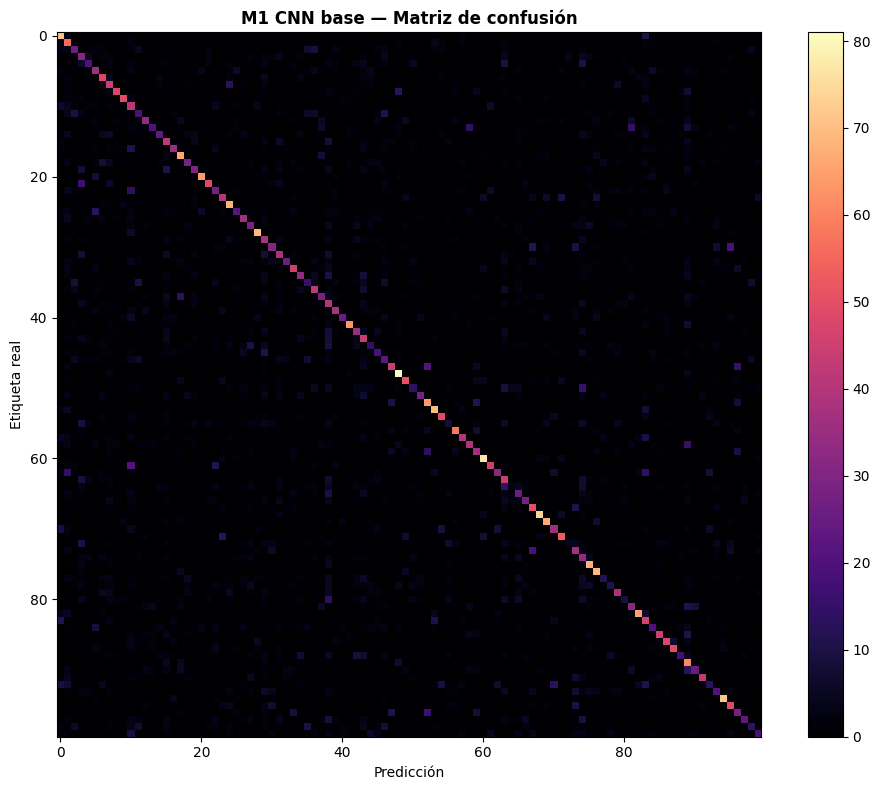

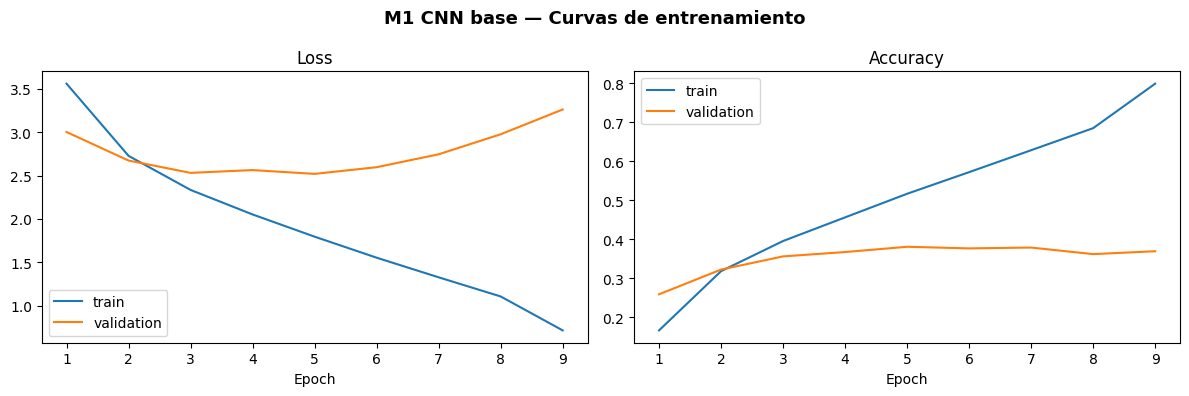

               precision    recall  f1-score   support

        apple       0.48      0.71      0.57       100
aquarium_fish       0.27      0.56      0.37       100
         baby       0.28      0.26      0.27       100
         bear       0.19      0.31      0.23       100
       beaver       0.33      0.20      0.25       100
          bed       0.31      0.36      0.33       100
          bee       0.36      0.48      0.41       100
       beetle       0.31      0.45      0.36       100
      bicycle       0.65      0.48      0.55       100
       bottle       0.56      0.49      0.52       100
         bowl       0.20      0.41      0.27       100
          boy       0.25      0.19      0.21       100
       bridge       0.48      0.34      0.40       100
          bus       0.45      0.20      0.28       100
    butterfly       0.41      0.24      0.30       100
        camel       0.26      0.42      0.32       100
          can       0.45      0.35      0.39       100
       ca

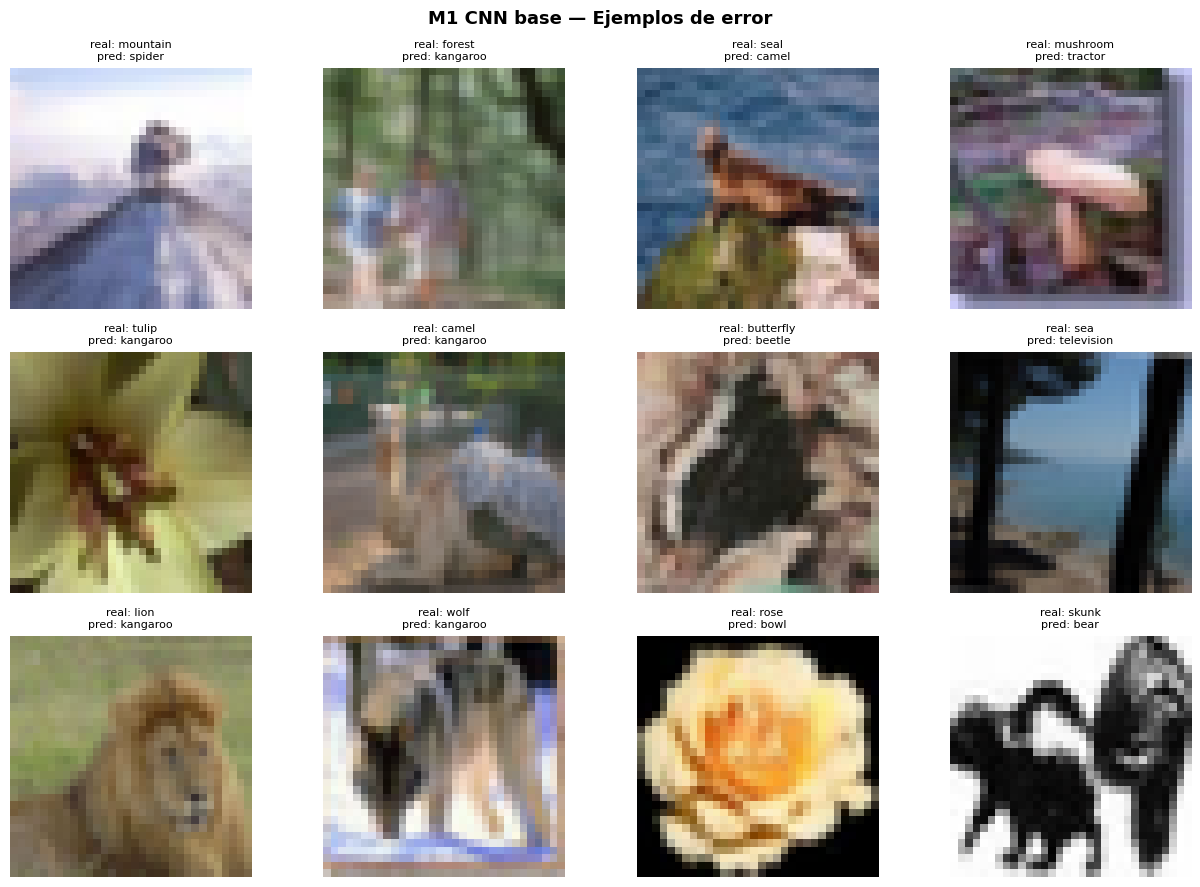

M1 CNN base
Parámetros entrenables : 1,093,924
Train accuracy         : 0.6054
Validation accuracy    : 0.3811
Test accuracy          : 0.3867
Gap train-val          : 0.2243
Comentarios            : Baseline sin augmentation y con arquitectura mínima.


In [ ]:
seed_everything()
m1_train_loader, m1_val_loader, m1_test_loader = build_split_loaders(transform_eval, transform_eval, batch_size=BATCH_SIZE)

class BaseCNN(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

m1_model = BaseCNN(num_classes=len(classes)).to(DEVICE)
m1_criterion = nn.CrossEntropyLoss()
m1_optimizer = optim.Adam(m1_model.parameters(), lr=1e-3)
m1_scheduler = optim.lr_scheduler.ReduceLROnPlateau(m1_optimizer, mode='min', factor=0.5, patience=2)
m1_history = train_model(m1_model, m1_train_loader, m1_val_loader, m1_criterion, m1_optimizer, epochs=epochs_for(12), scheduler=m1_scheduler, early_stopping=4)
m1_result = finalize_experiment('M1 CNN base', m1_model, m1_history, m1_train_loader, m1_val_loader, m1_test_loader, m1_criterion, transform_eval, CIFAR100_MEAN, CIFAR100_STD, notes='Baseline sin augmentation y con arquitectura mínima.')

## Interpretación del Modelo 1

Este resultado se usa como baseline. Si el accuracy es bajo 0.3867 o el gap 0.2243 entre train y validation crece mucho, eso indica que CIFAR-100 necesita modelos más potentes o mejor regularizados.

También sirve para identificar desde el principio qué clases generan más errores bear, kangoroo, otter, possom y qué tipo de confusiones aparecen.

# Modelo 2 - CNN Mejorada

## Objetivo del Modelo 2

El segundo modelo intenta mejorar el baseline usando una arquitectura más fuerte. Se añaden Batch Normalization, Dropout, más profundidad y Global Average Pooling para que el entrenamiento sea más estable y el modelo generalice mejor.

La hipótesis es que estas mejoras permitan aprender patrones más útiles sin caer tan fácilmente en overfitting.

Epoch 01/16 | train_loss=4.0051 | val_loss=3.6489 | train_acc=0.0827 | val_acc=0.1410 | 16.7s
Epoch 02/16 | train_loss=3.4911 | val_loss=3.2194 | train_acc=0.1681 | val_acc=0.2369 | 16.2s
Epoch 03/16 | train_loss=3.1960 | val_loss=2.9791 | train_acc=0.2303 | val_acc=0.2856 | 15.3s
Epoch 04/16 | train_loss=3.0029 | val_loss=2.8436 | train_acc=0.2759 | val_acc=0.3162 | 16.2s
Epoch 05/16 | train_loss=2.8476 | val_loss=2.6860 | train_acc=0.3109 | val_acc=0.3497 | 16.6s
Epoch 06/16 | train_loss=2.7201 | val_loss=2.7634 | train_acc=0.3446 | val_acc=0.3352 | 16.5s
Epoch 07/16 | train_loss=2.6209 | val_loss=2.4894 | train_acc=0.3709 | val_acc=0.4072 | 15.7s
Epoch 08/16 | train_loss=2.5267 | val_loss=2.4575 | train_acc=0.3910 | val_acc=0.4177 | 15.5s
Epoch 09/16 | train_loss=2.4474 | val_loss=2.4342 | train_acc=0.4160 | val_acc=0.4261 | 15.3s
Epoch 10/16 | train_loss=2.3769 | val_loss=2.2632 | train_acc=0.4329 | val_acc=0.4678 | 15.3s
Epoch 11/16 | train_loss=2.3125 | val_loss=2.3092 | train_ac

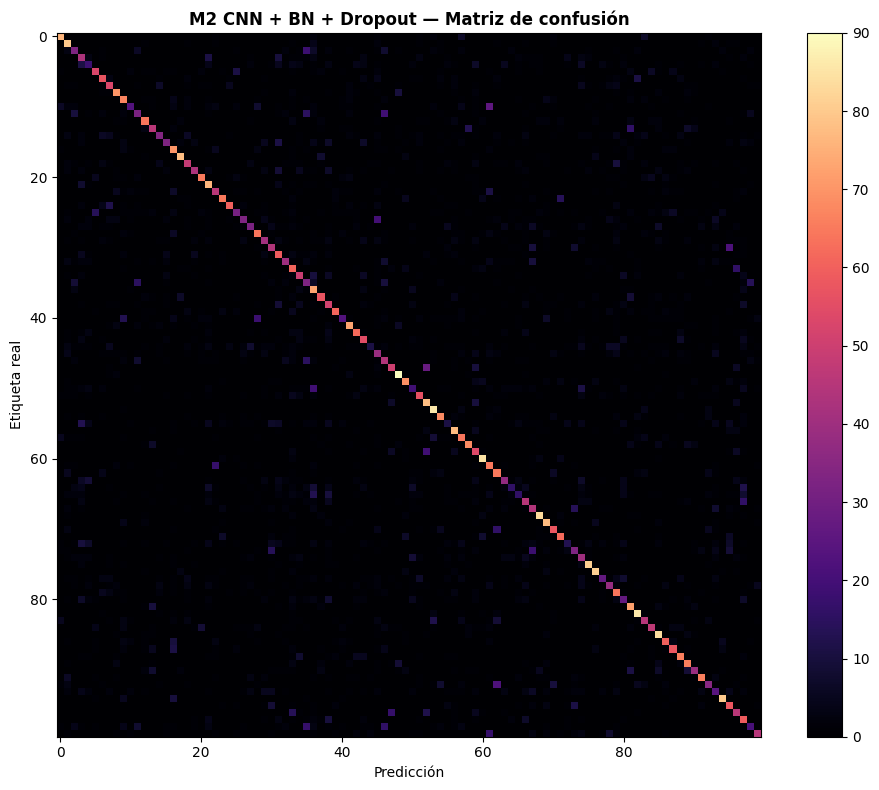

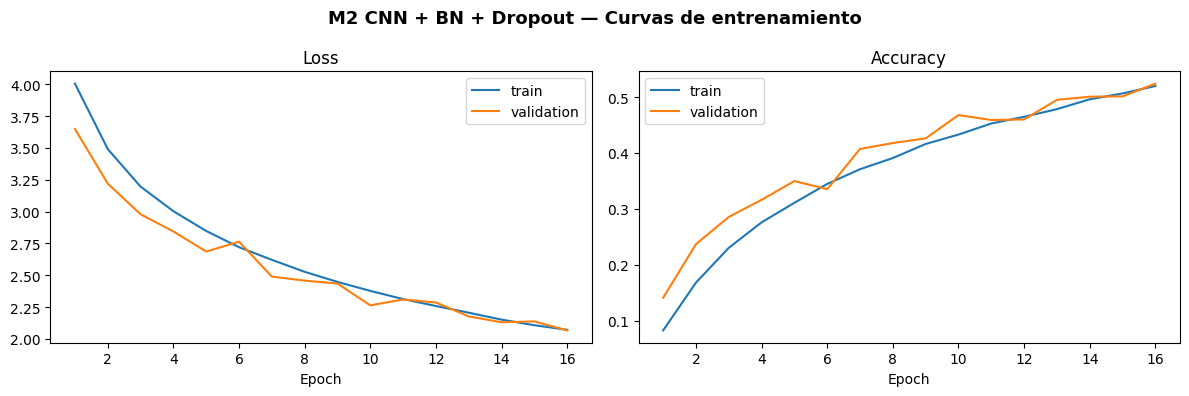

               precision    recall  f1-score   support

        apple       0.77      0.76      0.76       100
aquarium_fish       0.54      0.80      0.65       100
         baby       0.40      0.33      0.36       100
         bear       0.29      0.43      0.35       100
       beaver       0.26      0.18      0.21       100
          bed       0.64      0.53      0.58       100
          bee       0.58      0.57      0.58       100
       beetle       0.51      0.53      0.52       100
      bicycle       0.68      0.70      0.69       100
       bottle       0.51      0.67      0.58       100
         bowl       0.57      0.23      0.33       100
          boy       0.40      0.32      0.35       100
       bridge       0.70      0.64      0.67       100
          bus       0.51      0.46      0.48       100
    butterfly       0.55      0.34      0.42       100
        camel       0.57      0.33      0.42       100
          can       0.48      0.70      0.57       100
       ca

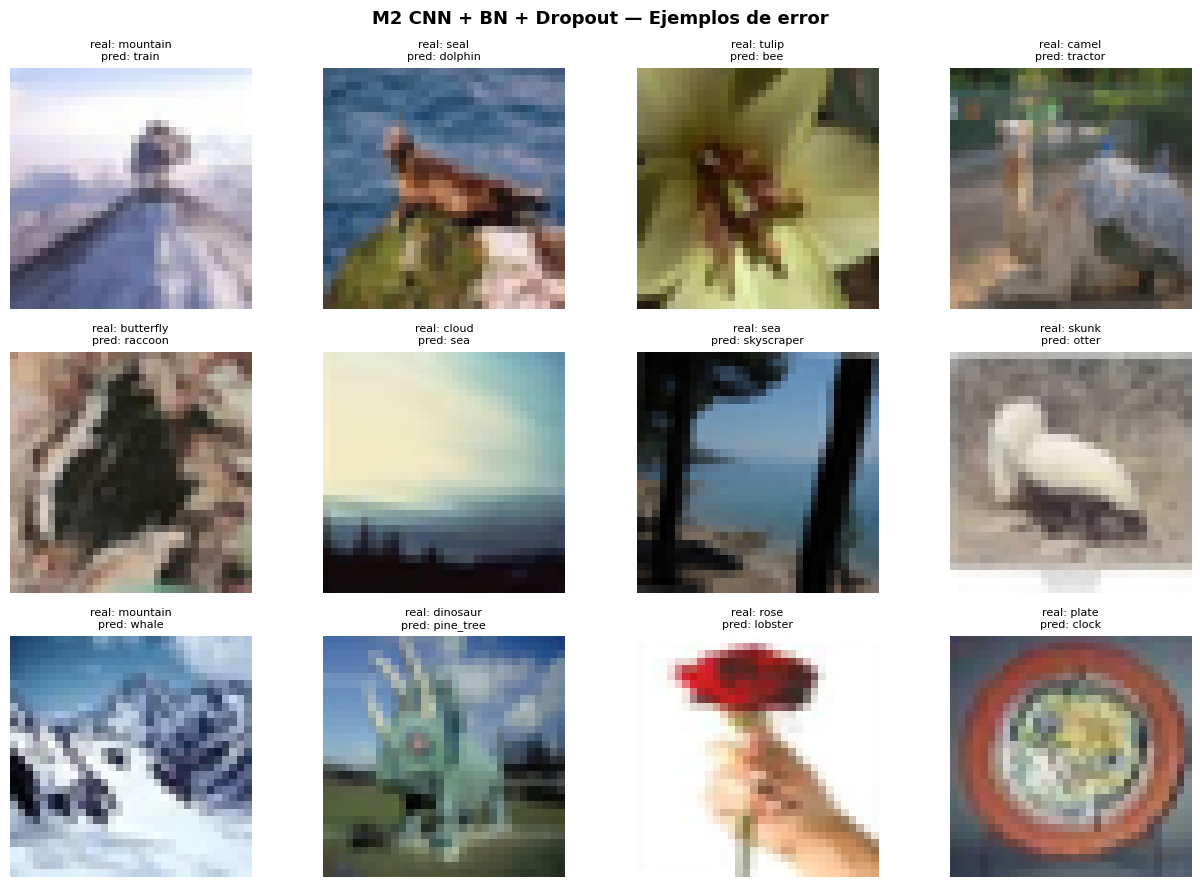

M2 CNN + BN + Dropout
Parámetros entrenables : 648,100
Train accuracy         : 0.6213
Validation accuracy    : 0.5239
Test accuracy          : 0.5273
Gap train-val          : 0.0974
Comentarios            : Arquitectura más profunda con BatchNorm, Dropout, GAP y AdamW.


In [ ]:
seed_everything()
m2_train_loader, m2_val_loader, m2_test_loader = build_split_loaders(transform_eval, transform_eval, batch_size=BATCH_SIZE)

class ImprovedCNN(nn.Module):
    def __init__(self, num_classes=100, dropout=0.35):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(dropout * 0.5),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(dropout),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

m2_model = ImprovedCNN(num_classes=len(classes)).to(DEVICE)
m2_criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
m2_optimizer = optim.AdamW(m2_model.parameters(), lr=1e-3, weight_decay=1e-4)
m2_scheduler = optim.lr_scheduler.ReduceLROnPlateau(m2_optimizer, mode='min', factor=0.5, patience=2)
m2_history = train_model(m2_model, m2_train_loader, m2_val_loader, m2_criterion, m2_optimizer, epochs=epochs_for(16), scheduler=m2_scheduler, early_stopping=5)
m2_result = finalize_experiment('M2 CNN + BN + Dropout', m2_model, m2_history, m2_train_loader, m2_val_loader, m2_test_loader, m2_criterion, transform_eval, CIFAR100_MEAN, CIFAR100_STD, notes='Arquitectura más profunda con BatchNorm, Dropout, GAP y AdamW.')

Interpretación Modelo 2

La comparación importante aquí es con el Modelo 1. Sube la accuracy 0.5273 y el gap sigue controlado 0.0974, se puede decir que la mejora de arquitectura aporta valor real.

Además bajan algunas confusiones frecuentes del baseline, eso refuerza la idea de que el modelo aprende representaciones más útiles.

# Modelo 3 - CNN + Data Augmentation

## Objetivo del Modelo 3

En este modelo se mantiene una CNN fuerte, pero se hace más exigente el augmentation. La idea es generar más variedad visual en train para que el modelo no dependa demasiado de la forma exacta en la que aparecen las imágenes originales.

En CIFAR-100 esto puede ayudar bastante, porque hay pocas imágenes por clase y muchas clases se parecen entre sí.

Epoch 01/20 | train_loss=4.1933 | val_loss=3.8886 | train_acc=0.0664 | val_acc=0.1186 | 37.2s
Epoch 02/20 | train_loss=3.8890 | val_loss=3.6695 | train_acc=0.1155 | val_acc=0.1686 | 37.2s
Epoch 03/20 | train_loss=3.7118 | val_loss=3.5632 | train_acc=0.1572 | val_acc=0.1974 | 37.6s
Epoch 04/20 | train_loss=3.5742 | val_loss=3.4445 | train_acc=0.1876 | val_acc=0.2263 | 35.7s
Epoch 05/20 | train_loss=3.4649 | val_loss=3.2297 | train_acc=0.2131 | val_acc=0.2718 | 37.0s
Epoch 06/20 | train_loss=3.3780 | val_loss=3.1380 | train_acc=0.2309 | val_acc=0.3031 | 38.0s
Epoch 07/20 | train_loss=3.3083 | val_loss=3.0768 | train_acc=0.2507 | val_acc=0.3155 | 37.1s
Epoch 08/20 | train_loss=3.2458 | val_loss=3.0321 | train_acc=0.2676 | val_acc=0.3311 | 37.8s
Epoch 09/20 | train_loss=3.1902 | val_loss=2.9595 | train_acc=0.2828 | val_acc=0.3515 | 37.1s
Epoch 10/20 | train_loss=3.1457 | val_loss=2.9104 | train_acc=0.2959 | val_acc=0.3683 | 36.5s
Epoch 11/20 | train_loss=3.1020 | val_loss=2.8663 | train_ac

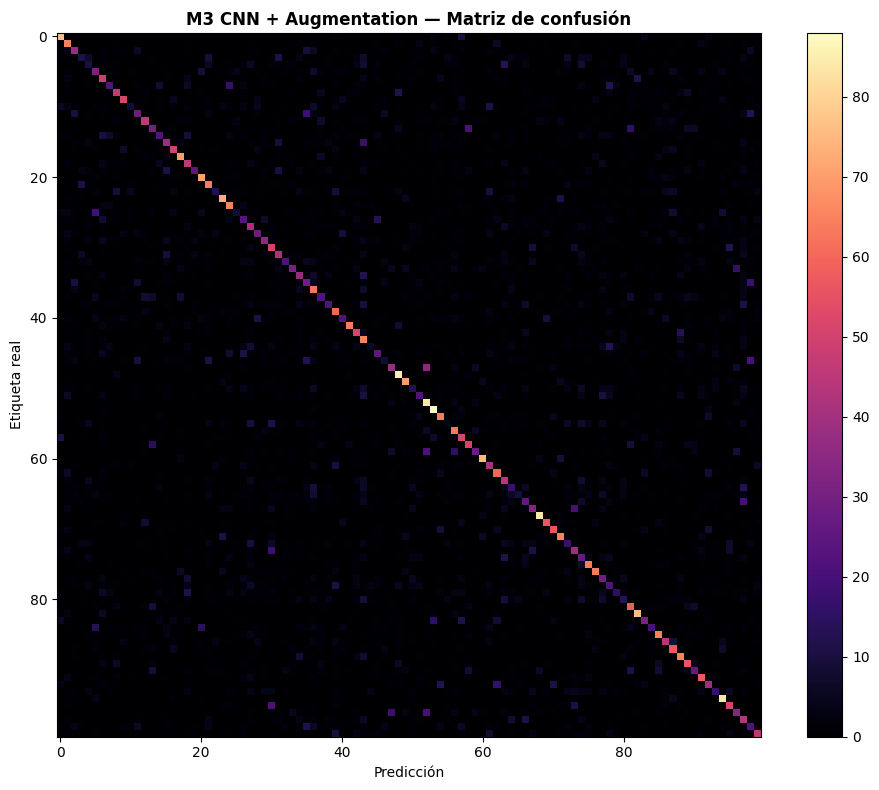

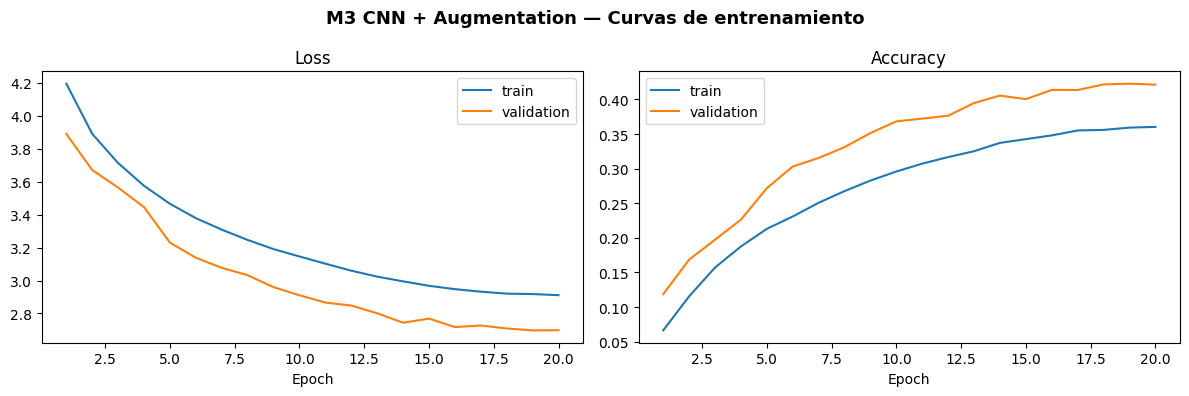

               precision    recall  f1-score   support

        apple       0.64      0.76      0.69       100
aquarium_fish       0.41      0.65      0.51       100
         baby       0.43      0.38      0.40       100
         bear       0.23      0.11      0.15       100
       beaver       0.14      0.10      0.12       100
          bed       0.31      0.31      0.31       100
          bee       0.34      0.49      0.40       100
       beetle       0.40      0.22      0.28       100
      bicycle       0.51      0.47      0.49       100
       bottle       0.63      0.52      0.57       100
         bowl       0.36      0.08      0.13       100
          boy       0.35      0.28      0.31       100
       bridge       0.53      0.46      0.49       100
          bus       0.36      0.30      0.33       100
    butterfly       0.37      0.23      0.28       100
        camel       0.37      0.38      0.37       100
          can       0.56      0.50      0.53       100
       ca

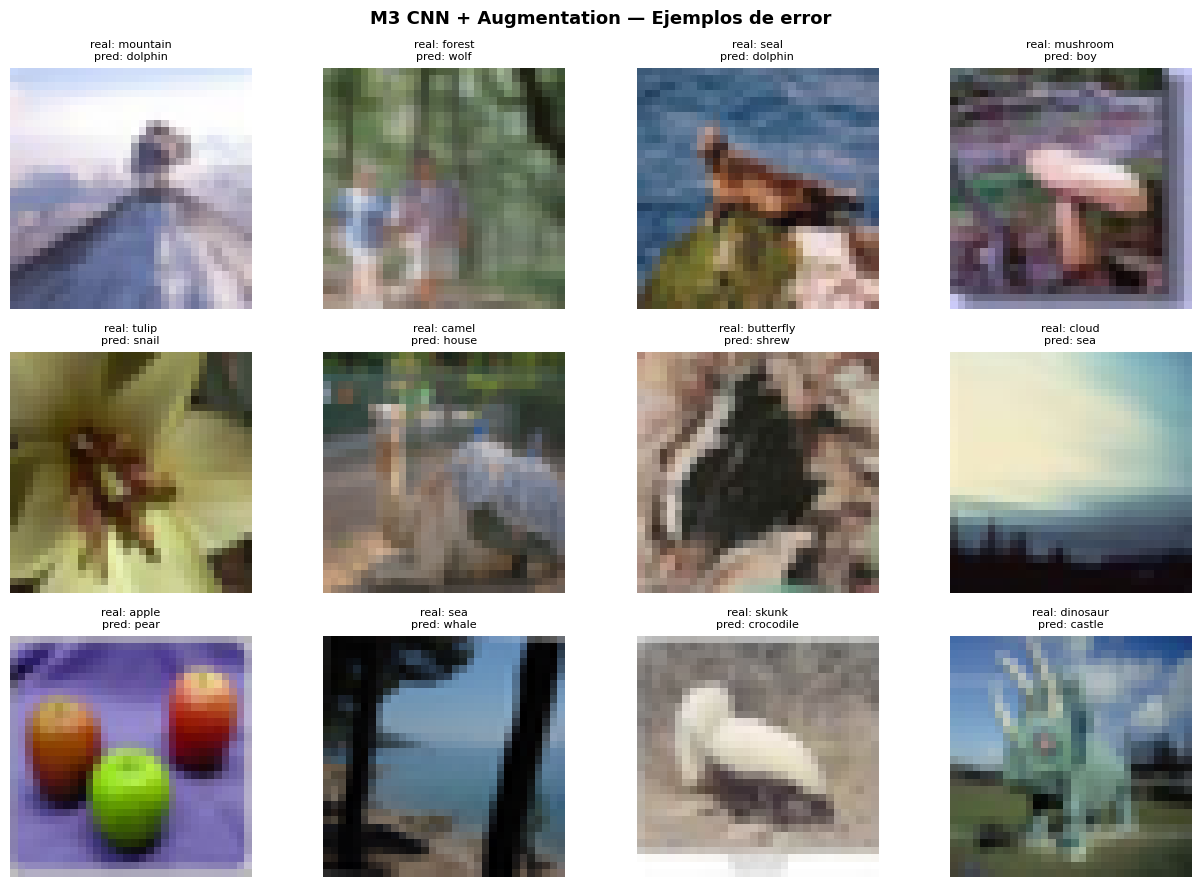

M3 CNN + Augmentation
Parámetros entrenables : 648,100
Train accuracy         : 0.4180
Validation accuracy    : 0.4228
Test accuracy          : 0.4224
Gap train-val          : -0.0048
Comentarios            : Misma familia de CNN, pero con augmentation fuerte, RandomErasing y label smoothing.


In [ ]:
seed_everything()
transform_train_strong = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.25),
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR100_MEAN, std=CIFAR100_STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.12), value='random'),
])

m3_train_loader, m3_val_loader, m3_test_loader = build_split_loaders(transform_train_strong, transform_eval, batch_size=BATCH_SIZE)
m3_model = ImprovedCNN(num_classes=len(classes), dropout=0.40).to(DEVICE)
m3_criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
m3_optimizer = optim.AdamW(m3_model.parameters(), lr=8e-4, weight_decay=2e-4)
m3_scheduler = optim.lr_scheduler.CosineAnnealingLR(m3_optimizer, T_max=epochs_for(20))
m3_history = train_model(m3_model, m3_train_loader, m3_val_loader, m3_criterion, m3_optimizer, epochs=epochs_for(20), scheduler=m3_scheduler, early_stopping=6)
m3_result = finalize_experiment('M3 CNN + Augmentation', m3_model, m3_history, m3_train_loader, m3_val_loader, m3_test_loader, m3_criterion, transform_eval, CIFAR100_MEAN, CIFAR100_STD, notes='Misma familia de CNN, pero con augmentation fuerte, RandomErasing y label smoothing.')

Interpretación del Modelo 3

Aquí no subió la accuracy de train. De hecho, la validation y test empeoraron.
El augmentation está perjudicando la generalizada.

Aunque este modelo debe leerse sobre todo desde la perspectiva de robustez y control del overfitting no obtuvo buenas métricas.

# Modelo 4 - CNN + Técnicas Clásicas

## Objetivo del Modelo 4

Este modelo conecta la parte de visión clásica con la parte de Deep Learning. Antes de entrenar la CNN, las imágenes pasan por un pipeline clásico para intentar resaltar detalles útiles.

La pregunta que se quiere responder es sencilla: ¿estas técnicas clásicas ayudan de verdad a clasificar mejor o solo cambian la imagen sin aportar mejora real?

Epoch 01/18 | train_loss=3.9720 | val_loss=3.7522 | train_acc=0.0864 | val_acc=0.1341 | 51.1s
Epoch 02/18 | train_loss=3.5098 | val_loss=3.3562 | train_acc=0.1667 | val_acc=0.2062 | 51.2s
Epoch 03/18 | train_loss=3.3006 | val_loss=3.3318 | train_acc=0.2130 | val_acc=0.2227 | 50.5s
Epoch 04/18 | train_loss=3.1613 | val_loss=2.9913 | train_acc=0.2451 | val_acc=0.2842 | 50.5s
Epoch 05/18 | train_loss=3.0346 | val_loss=3.1552 | train_acc=0.2718 | val_acc=0.2700 | 52.2s
Epoch 06/18 | train_loss=2.9379 | val_loss=3.1013 | train_acc=0.2948 | val_acc=0.2868 | 51.8s
Epoch 07/18 | train_loss=2.8715 | val_loss=2.7480 | train_acc=0.3132 | val_acc=0.3476 | 51.0s
Epoch 08/18 | train_loss=2.7839 | val_loss=2.8335 | train_acc=0.3348 | val_acc=0.3365 | 51.2s
Epoch 09/18 | train_loss=2.7234 | val_loss=2.6339 | train_acc=0.3503 | val_acc=0.3804 | 50.3s
Epoch 10/18 | train_loss=2.6671 | val_loss=2.5867 | train_acc=0.3631 | val_acc=0.3872 | 50.9s
Epoch 11/18 | train_loss=2.6187 | val_loss=2.4712 | train_ac

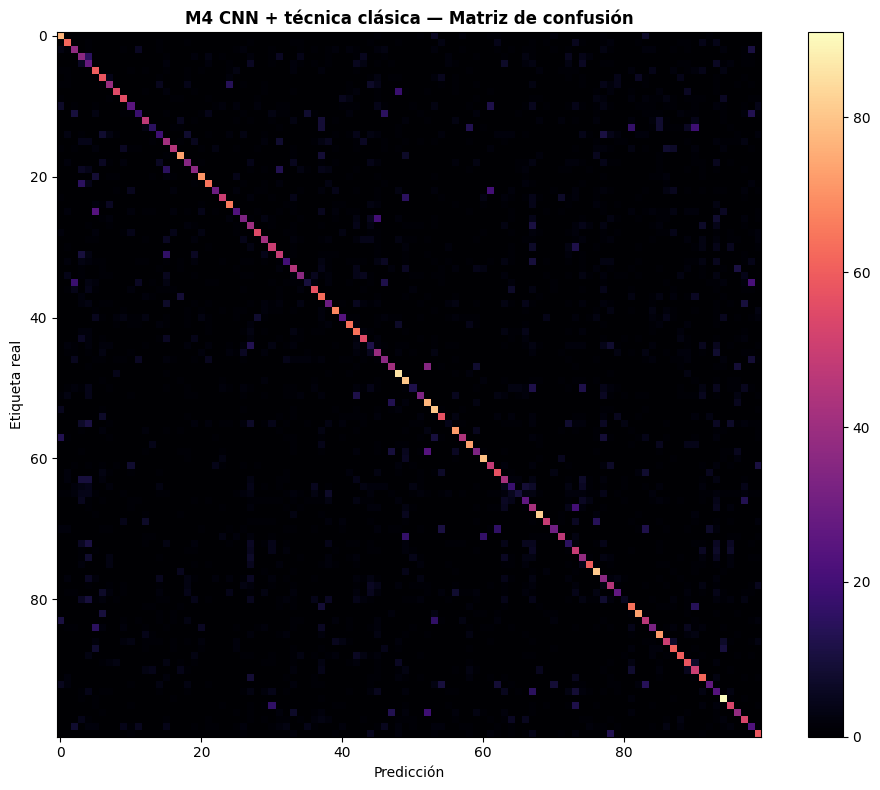

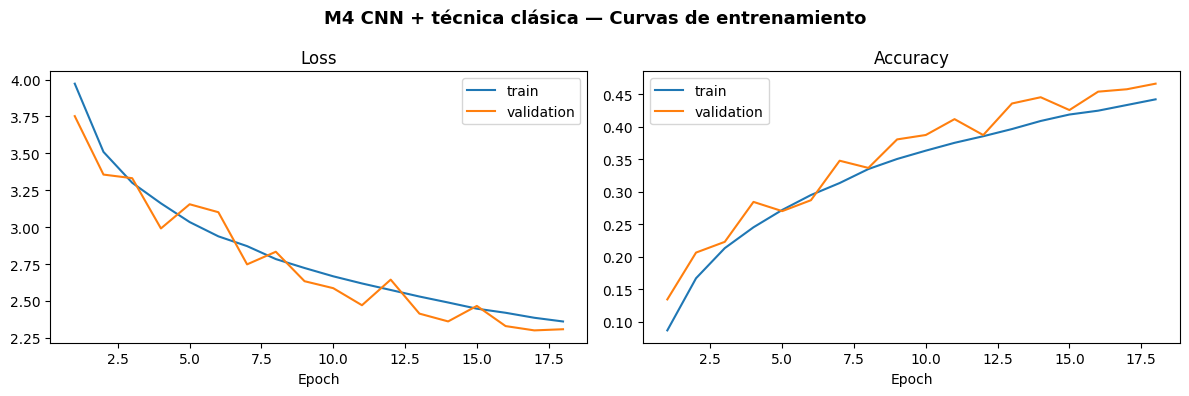

               precision    recall  f1-score   support

        apple       0.58      0.77      0.66       100
aquarium_fish       0.60      0.62      0.61       100
         baby       0.39      0.37      0.38       100
         bear       0.24      0.36      0.29       100
       beaver       0.17      0.28      0.21       100
          bed       0.40      0.60      0.48       100
          bee       0.45      0.58      0.50       100
       beetle       0.48      0.39      0.43       100
      bicycle       0.77      0.55      0.64       100
       bottle       0.64      0.56      0.60       100
         bowl       0.40      0.25      0.31       100
          boy       0.38      0.18      0.24       100
       bridge       0.55      0.47      0.51       100
          bus       0.47      0.15      0.23       100
    butterfly       0.32      0.19      0.24       100
        camel       0.31      0.41      0.35       100
          can       0.71      0.45      0.55       100
       ca

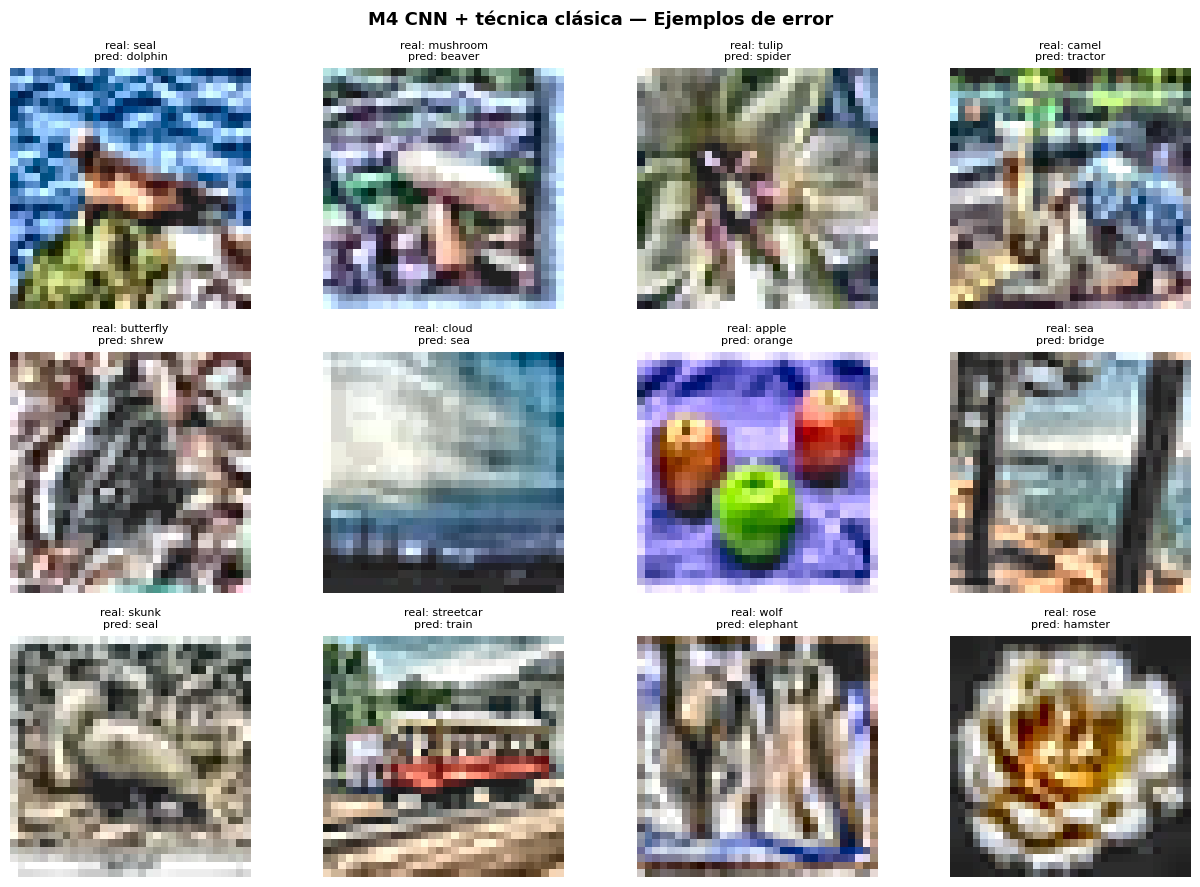

M4 CNN + técnica clásica
Parámetros entrenables : 648,100
Train accuracy         : 0.5209
Validation accuracy    : 0.4662
Test accuracy          : 0.4630
Gap train-val          : 0.0547
Comentarios            : Pipeline híbrido con linear stretch + CLAHE antes de entrenar la CNN.


In [ ]:
seed_everything()

def classic_pipeline(img_np):
    img_np = linear_stretch(img_np, low_pct=2, high_pct=98)
    return apply_clahe(img_np, clip_limit=2.0, tile_grid=(8, 8))

transform_classic_train = transforms.Compose([
    transforms.Lambda(lambda pil_img: np.array(pil_img)),
    transforms.Lambda(classic_pipeline),
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR100_MEAN, std=CIFAR100_STD),
])
transform_classic_eval = build_processed_transform(classic_pipeline)

m4_train_loader, m4_val_loader, m4_test_loader = build_split_loaders(transform_classic_train, transform_classic_eval, batch_size=BATCH_SIZE)
m4_model = ImprovedCNN(num_classes=len(classes), dropout=0.35).to(DEVICE)
m4_criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
m4_optimizer = optim.AdamW(m4_model.parameters(), lr=8e-4, weight_decay=1e-4)
m4_scheduler = optim.lr_scheduler.ReduceLROnPlateau(m4_optimizer, mode='min', factor=0.5, patience=2)
m4_history = train_model(m4_model, m4_train_loader, m4_val_loader, m4_criterion, m4_optimizer, epochs=epochs_for(18), scheduler=m4_scheduler, early_stopping=5)
m4_result = finalize_experiment('M4 CNN + técnica clásica', m4_model, m4_history, m4_train_loader, m4_val_loader, m4_test_loader, m4_criterion, transform_classic_eval, CIFAR100_MEAN, CIFAR100_STD, notes='Pipeline híbrido con linear stretch + CLAHE antes de entrenar la CNN.')

Interpretación del Modelo 4

La comparación clave aquí es con los modelos CNN sin pipeline clásico. Este modelo obtuvo en validation 0.4662 y test 0.4630, no todo cambio visual que parece interesante termina ayudando a la clasificación.

# Modelo 5 - Transfer Learning

## Objetivo del Modelo 5

El transfer learning intenta aprovechar conocimiento aprendido previamente sobre muchas imágenes. En vez de empezar desde cero, se usa una red preentrenada y se adapta al problema de CIFAR-100.

En este caso se prueban tres fases: congelar casi toda la red, afinar solo una parte y finalmente hacer un ajuste más profundo. Así se puede ver qué nivel de fine tuning funciona mejor.

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 150MB/s]


========== Fase: freeze ==========


Epoch 01/05 | train_loss=2.7347 | val_loss=2.3782 | train_acc=0.4356 | val_acc=0.5306 | 94.6s
Epoch 02/05 | train_loss=2.3595 | val_loss=2.3242 | train_acc=0.5315 | val_acc=0.5492 | 95.2s
Epoch 03/05 | train_loss=2.3094 | val_loss=2.2989 | train_acc=0.5495 | val_acc=0.5590 | 95.2s
Epoch 04/05 | train_loss=2.2925 | val_loss=2.2911 | train_acc=0.5527 | val_acc=0.5634 | 95.1s
Epoch 05/05 | train_loss=2.2714 | val_loss=2.2893 | train_acc=0.5611 | val_acc=0.5629 | 96.8s

========== Fase: partial ==========
Epoch 01/05 | train_loss=2.0866 | val_loss=1.8776 | train_acc=0.5928 | val_acc=0.6631 | 98.9s
Epoch 02/05 | train_loss=1.7746 | val_loss=1.7988 | train_acc=0.6915 | val_acc=0.6827 | 98.3s
Epoch 03/05 | train_loss=1.6356 | val_loss=1.7372 | train_acc=0.7412 | val_acc=0.7054 | 96.4s
Epoch 04/05 | train_loss=1.5230 | val_loss=1.7327 | train_acc=0.7789 | val_acc=0.7120 | 96.1s
Epoch 05/05 | train_loss=1.4383 | val_loss=1.7210 | train_acc=0.8104 | val_acc=0.7144 | 97.5s

========== Fase: deep 

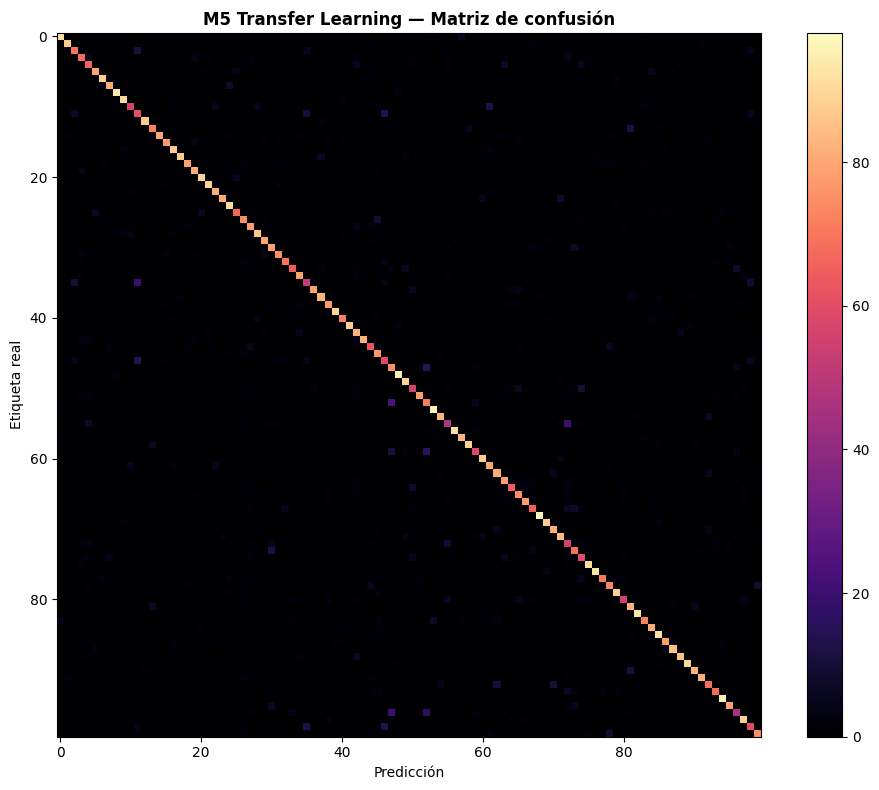

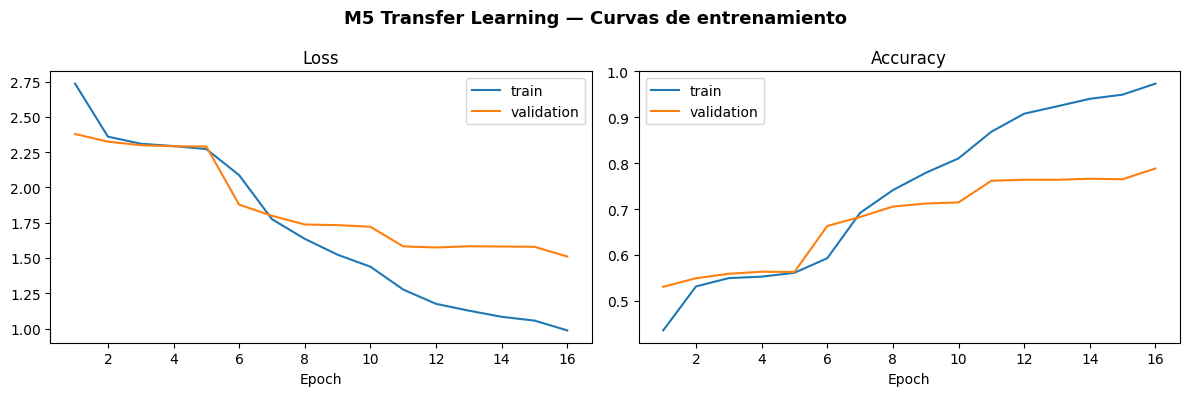

               precision    recall  f1-score   support

        apple       0.90      0.92      0.91       100
aquarium_fish       0.85      0.88      0.86       100
         baby       0.71      0.70      0.70       100
         bear       0.71      0.68      0.69       100
       beaver       0.61      0.66      0.63       100
          bed       0.84      0.79      0.81       100
          bee       0.81      0.88      0.84       100
       beetle       0.79      0.81      0.80       100
      bicycle       0.91      0.94      0.93       100
       bottle       0.91      0.90      0.90       100
         bowl       0.77      0.57      0.66       100
          boy       0.53      0.61      0.56       100
       bridge       0.90      0.87      0.88       100
          bus       0.81      0.72      0.76       100
    butterfly       0.85      0.80      0.82       100
        camel       0.84      0.78      0.81       100
          can       0.81      0.87      0.84       100
       ca

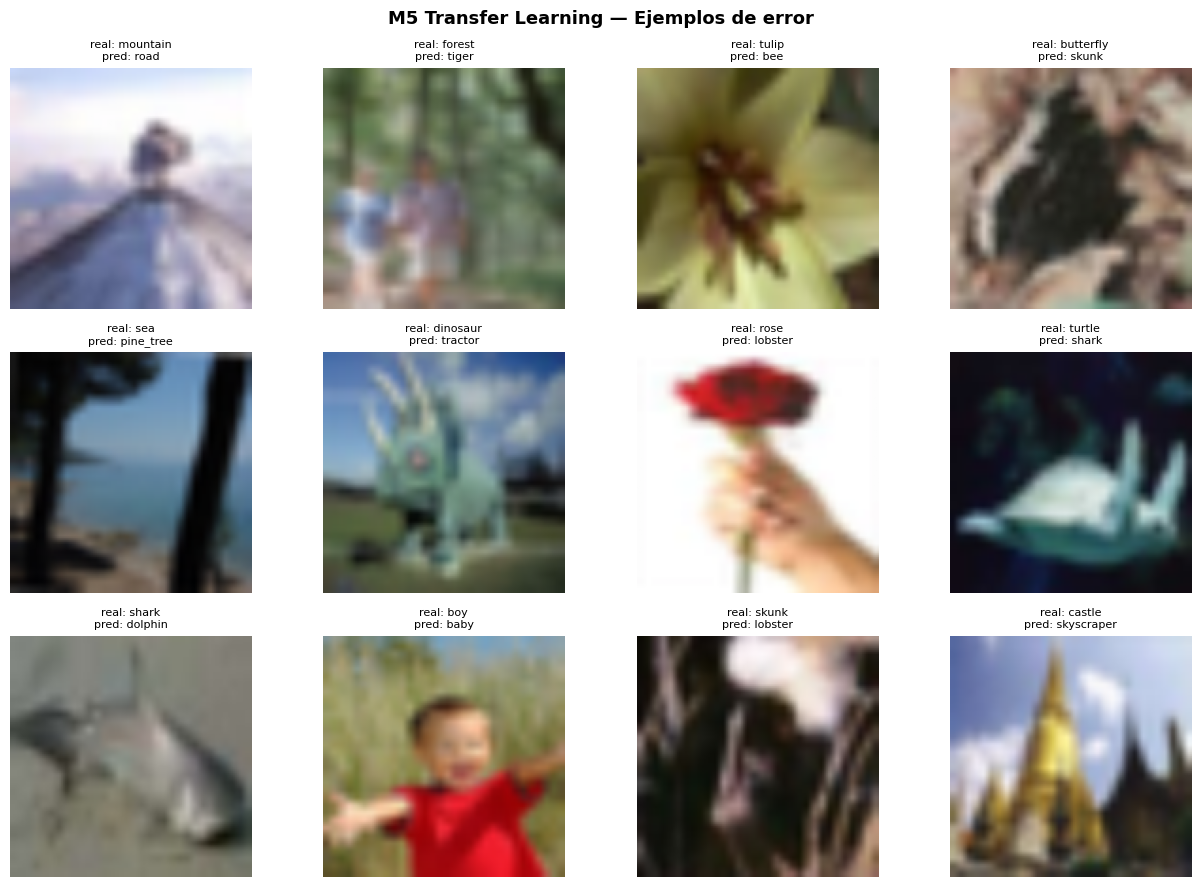

M5 Transfer Learning
Parámetros entrenables : 11,227,812
Train accuracy         : 0.9895
Validation accuracy    : 0.7884
Test accuracy          : 0.7802
Gap train-val          : 0.2011
Comentarios            : ResNet18 preentrenada con tres fases: freezing, fine tuning parcial y fine tuning profundo.


In [ ]:
seed_everything()
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
TL_SIZE = 128
TL_BATCH_SIZE = 32 if DEVICE.type == 'cuda' else 16

transform_tl_train = transforms.Compose([
    transforms.Resize((TL_SIZE + 16, TL_SIZE + 16)),
    transforms.RandomResizedCrop(TL_SIZE, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
transform_tl_eval = transforms.Compose([
    transforms.Resize((TL_SIZE, TL_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

m5_train_loader, m5_val_loader, m5_test_loader = build_split_loaders(transform_tl_train, transform_tl_eval, batch_size=TL_BATCH_SIZE)

m5_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
m5_model.fc = nn.Linear(m5_model.fc.in_features, len(classes))
m5_model = m5_model.to(DEVICE)
m5_criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

def set_trainable(module, flag):
    for param in module.parameters():
        param.requires_grad = flag

def configure_resnet18_phase(model, phase):
    if phase == 'freeze':
        set_trainable(model, False)
        set_trainable(model.fc, True)
    elif phase == 'partial':
        set_trainable(model, False)
        set_trainable(model.layer4, True)
        set_trainable(model.fc, True)
    elif phase == 'deep':
        set_trainable(model, True)
    else:
        raise ValueError(f'Fase desconocida: {phase}')

m5_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
phase_plan = [
    ('freeze', 1e-3, epochs_for(5)),
    ('partial', 3e-4, epochs_for(5)),
    ('deep', 1e-4, epochs_for(6)),
]

for phase_name, lr, phase_epochs in phase_plan:
    print(f'\n========== Fase: {phase_name} ==========' )
    configure_resnet18_phase(m5_model, phase_name)
    phase_optimizer = optim.AdamW(filter(lambda p: p.requires_grad, m5_model.parameters()), lr=lr, weight_decay=1e-4)
    phase_scheduler = optim.lr_scheduler.ReduceLROnPlateau(phase_optimizer, mode='min', factor=0.5, patience=2)
    phase_history = train_model(m5_model, m5_train_loader, m5_val_loader, m5_criterion, phase_optimizer, epochs=phase_epochs, scheduler=phase_scheduler, early_stopping=3)
    m5_history = extend_history(m5_history, phase_history)

m5_result = finalize_experiment('M5 Transfer Learning', m5_model, m5_history, m5_train_loader, m5_val_loader, m5_test_loader, m5_criterion, transform_tl_eval, IMAGENET_MEAN, IMAGENET_STD, notes='ResNet18 preentrenada con tres fases: freezing, fine tuning parcial y fine tuning profundo.')

## Interpretacion del Modelo 5

Este modelo fué el candidato más fuerte porque parte de una red que ya ha aprendido representaciones visuales útiles. Acá se pudo comprobar que eso se traduce en mejor accuracy en validation 0.7884 y test 0.7802, y con un gap que sigue siendo razonable 0.2011.
El ajuste profundo mejora al parcial pero empieza a provocar más overfitting.

# Comparación final y control de overfitting

En esta parte ya no interesa mirar un solo modelo por separado, sino compararlos entre sí. Para eso se revisan dos cosas: el accuracy en test y el gap entre train y validation.

La idea es simple: un modelo bueno no es solo el que más acierta, sino el que también generaliza bien. Si el train es mucho mayor que validation, hay señales de overfitting.

Modelo                          Train      Val     Test      Gap  Comentario
M5 Transfer Learning           0.9895   0.7884   0.7802   0.2011  Overfitting claro
M2 CNN + BN + Dropout          0.6213   0.5239   0.5273   0.0974  Posible overfitting
M4 CNN + técnica clásica       0.5209   0.4662   0.4630   0.0547  Generalización correcta
M3 CNN + Augmentation          0.4180   0.4228   0.4224  -0.0048  Excelente generalización
M1 CNN base                    0.6054   0.3811   0.3867   0.2243  Overfitting claro


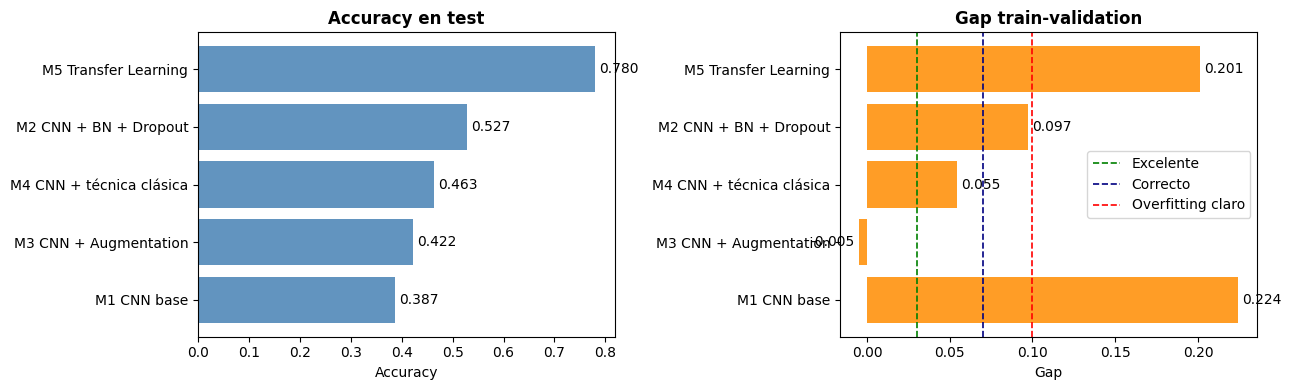

Mejor modelo por accuracy en test: M5 Transfer Learning (0.7802)


In [ ]:
summary_rows = []
for result in MODEL_RESULTS.values():
    gap = result['gap']
    if gap < 0.03:
        gap_comment = 'Excelente generalización'
    elif gap <= 0.07:
        gap_comment = 'Generalización correcta'
    elif gap <= 0.10:
        gap_comment = 'Posible overfitting'
    else:
        gap_comment = 'Overfitting claro'

    summary_rows.append({
        'Modelo': result['name'],
        'Técnicas usadas': result['notes'],
        'Train acc': result['train_acc'],
        'Val acc': result['val_acc'],
        'Test acc': result['test_acc'],
        'Gap': result['gap'],
        'Comentarios': gap_comment,
    })

summary_rows = sorted(summary_rows, key=lambda row: row['Test acc'], reverse=True)

print('=' * 100)
print(f"{'Modelo':<28} {'Train':>8} {'Val':>8} {'Test':>8} {'Gap':>8}  Comentario")
print('=' * 100)
for row in summary_rows:
    print(f"{row['Modelo']:<28} {row['Train acc']:>8.4f} {row['Val acc']:>8.4f} {row['Test acc']:>8.4f} {row['Gap']:>8.4f}  {row['Comentarios']}")
print('=' * 100)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
model_names = [row['Modelo'] for row in summary_rows]
test_scores = [row['Test acc'] for row in summary_rows]
gaps = [row['Gap'] for row in summary_rows]

bars_1 = axes[0].barh(model_names, test_scores, color='steelblue', alpha=0.85)
axes[0].set_title('Accuracy en test', fontweight='bold')
axes[0].set_xlabel('Accuracy')
axes[0].bar_label(bars_1, fmt='%.3f', padding=3)
axes[0].invert_yaxis()

bars_2 = axes[1].barh(model_names, gaps, color='darkorange', alpha=0.85)
axes[1].axvline(0.03, linestyle='--', color='green', linewidth=1.2, label='Excelente')
axes[1].axvline(0.07, linestyle='--', color='navy', linewidth=1.2, label='Correcto')
axes[1].axvline(0.10, linestyle='--', color='red', linewidth=1.2, label='Overfitting claro')
axes[1].set_title('Gap train-validation', fontweight='bold')
axes[1].set_xlabel('Gap')
axes[1].bar_label(bars_2, fmt='%.3f', padding=3)
axes[1].invert_yaxis()
axes[1].legend()

plt.tight_layout()
plt.show()

best_result = max(MODEL_RESULTS.values(), key=lambda item: item['test_acc'])
print(f"Mejor modelo por accuracy en test: {best_result['name']} ({best_result['test_acc']:.4f})")

# Imágenes externas



El test interno del dataset es útil, pero sigue perteneciendo a la misma distribución que CIFAR-100. Las imágenes externas sirven para comprobar si el modelo también funciona en ejemplos más reales, con otros fondos, otros encuadres o distinta iluminación.

Por eso esta parte es una prueba sencilla de generalización fuera del dataset original.

In [8]:
import torch.nn as nn
from torchvision import models
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Reconstruir la arquitectura igual que en el entrenamiento
m5_model = models.resnet18(weights=None)
m5_model.fc = nn.Linear(m5_model.fc.in_features, len(classes))

# Cargar los pesos
checkpoint = torch.load('/content/m5_transfer_learning.pt', map_location=DEVICE, weights_only=False)

# Ver qué contiene
print(checkpoint.keys())  # → 'state_dict', 'class_names', 'result'

# Recuperar clases directamente del checkpoint
classes = checkpoint['class_names']
print(classes)

# Reconstruir el modelo con el número correcto de clases
m5_model = models.resnet18(weights=None)
m5_model.fc = nn.Linear(m5_model.fc.in_features, len(classes))

# Cargar solo los pesos
m5_model.load_state_dict(checkpoint['state_dict'])
m5_model = m5_model.to(DEVICE)
m5_model.eval()

dict_keys(['state_dict', 'class_names', 'result'])
['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tu

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [21]:
from torchvision import transforms

mean = checkpoint['result']['mean']
std  = checkpoint['result']['std']

transform_tl_eval = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

In [23]:
import numpy as np

def tensor_to_numpy_with_stats(tensor, mean, std):
    img = tensor.clone().numpy() if not isinstance(tensor, np.ndarray) else tensor
    img = img.transpose(1, 2, 0)  # [C, H, W] → [H, W, C]
    img = img * np.array(std) + np.array(mean)  # desnormalizar
    img = np.clip(img, 0, 1)
    return img

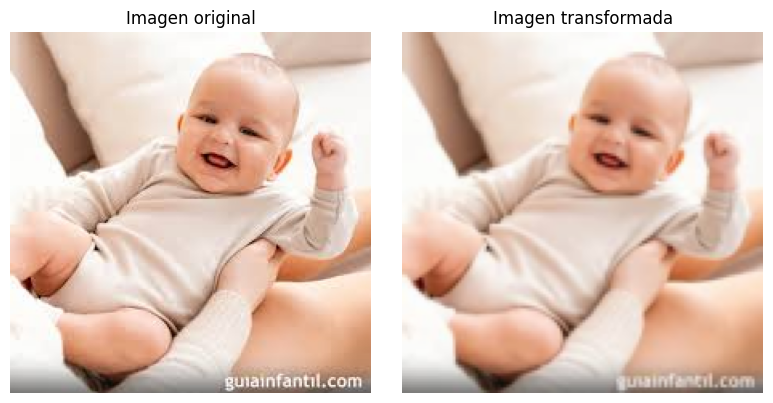

Archivo      : /content/external_images/bebe.jpg
Predicción   : baby (0.3409)
Top-5:
  baby                 0.3409
  snake                0.1314
  boy                  0.0654
  couch                0.0385
  plate                0.0249


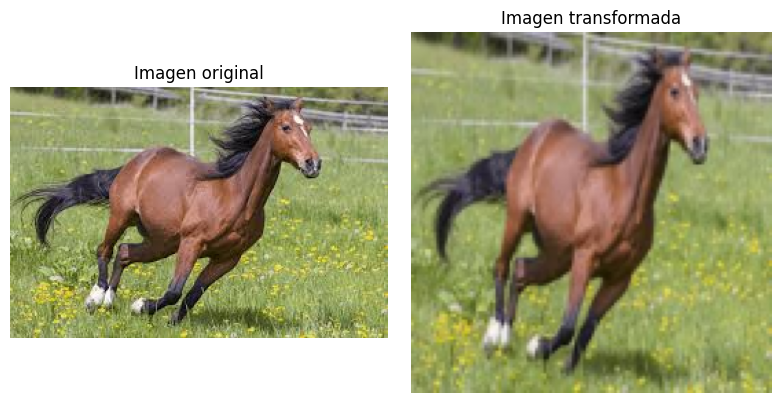

Archivo      : /content/external_images/horse.jpg
Predicción   : leopard (0.1815)
Top-5:
  leopard              0.1815
  camel                0.0500
  butterfly            0.0453
  shrew                0.0427
  seal                 0.0411


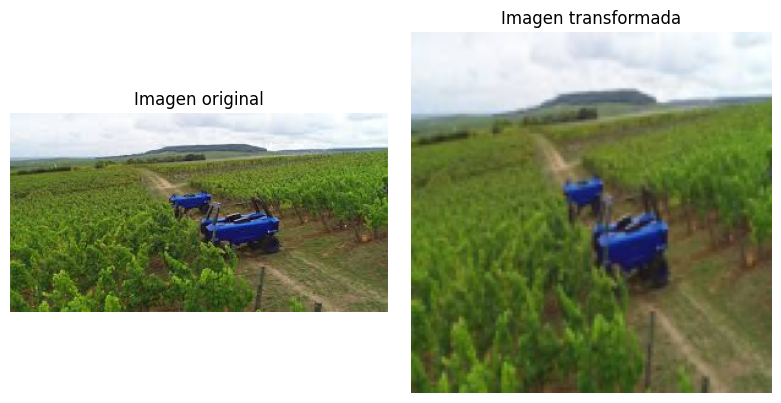

Archivo      : /content/external_images/lawn_mower.jpg
Predicción   : plain (0.1858)
Top-5:
  plain                0.1858
  beetle               0.1010
  sea                  0.0341
  leopard              0.0341
  porcupine            0.0319


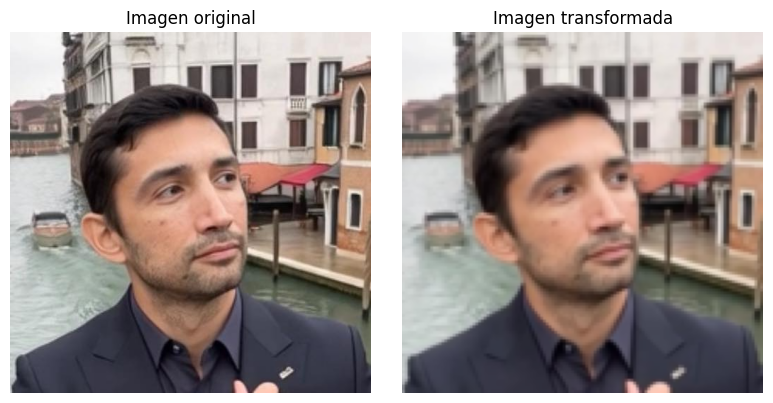

Archivo      : /content/external_images/man.jpg
Predicción   : man (0.5418)
Top-5:
  man                  0.5418
  boy                  0.1508
  woman                0.0489
  baby                 0.0145
  butterfly            0.0131


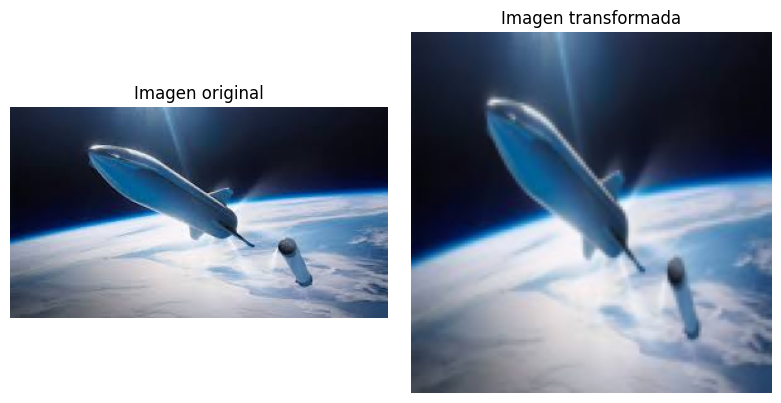

Archivo      : /content/external_images/rocket.jpg
Predicción   : dolphin (0.1213)
Top-5:
  dolphin              0.1213
  cup                  0.0788
  rocket               0.0665
  seal                 0.0593
  aquarium_fish        0.0586


In [26]:
from pathlib import Path
external_dir = Path('/content/external_images')

def predict_external_image(model, image_path, transform, device=DEVICE):
    from PIL import Image

    image = Image.open(image_path).convert('RGB')
    tensor = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1)[0].cpu().numpy()

    top5_idx = probs.argsort()[-5:][::-1]
    return {
        'original': image,
        'resized': transform(image),
        'pred_idx': int(top5_idx[0]),
        'pred_label': classes[int(top5_idx[0])],
        'pred_prob': float(probs[top5_idx[0]]),
        'top5': [(classes[int(idx)], float(probs[idx])) for idx in top5_idx],
    }

best_model = m5_model
best_model.eval()
external_paths = sorted([p for p in external_dir.rglob('*') if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}])[:5]

if len(external_paths) < 5:
    print('Añade al menos 5 imágenes externas para completar esta sección.')
else:
    for image_path in external_paths:
        result = predict_external_image(best_model, image_path, transform_tl_eval)
        resized_np = tensor_to_numpy_with_stats(result['resized'], mean=mean, std=std)
        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].imshow(result['original'])
        axes[0].set_title('Imagen original')
        axes[0].axis('off')

        axes[1].imshow(resized_np)
        axes[1].set_title('Imagen transformada')
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()

        print(f'Archivo      : {image_path}')
        print(f'Predicción   : {result["pred_label"]} ({result["pred_prob"]:.4f})')
        print('Top-5:')
        for label, prob in result['top5']:
            print(f'  {label:20s} {prob:.4f}')


El mejor modelo se puede afinar mas hay predicciones que estan cerca a la real. Se cumple el 75 porciento de precision aproximadamente. Según claude se pudiera mejorar el modelo al implementar TTA promediando predicciones sobre múltiples versiones de cada imagen sin reentrenar, añadir augmentations como RandomErasing y MixUp para mejorar la generalización, y reemplazar ReduceLROnPlateau por CosineAnnealingLR junto a una fase final de fine-tuning completo con learning rate de 1e-5.

========================================================================
CONCLUSIONES DEL RETO
========================================================================
1. ¿Qué modelo funcionó mejor?
   M5 Transfer Learning con test accuracy = 0.7802.

2. ¿Qué técnicas ayudaron realmente?
   La augmentation no ayudó y las técnicas clásicas no aportaron mejora. M5 lidera, el transfer learning fue la estrategia más efectiva.

3. ¿Qué clases generan más confusión?
   Principales confusiones del mejor modelo: oak_tree->maple_tree (24) | willow_tree->maple_tree (20) | otter->seal (20) | girl->boy (19) | willow_tree->oak_tree (16)

4. ¿Dónde falla el modelo?
   Revisar los ejemplos de error y la matriz de confusión para detectar clases con poca textura, objetos pequeños o gran similitud semántica.

5. ¿Qué técnicas clásicas aportaron mejora?
   Probablemente introdujeron distorsiones no alineadas con la clasificación, habria que probar mas para sacar un juicio definitivo pero solo superaron el baseline y la augmentation aunque controlaron el overfiting y aportaron una excelente generalizacion.

6. ¿El modelo generaliza correctamente?
   El modelo con menor gap es M3 CNN + Augmentation con gap = -0.0048.

7. ¿Se alcanzó el objetivo de accuracy >= 0.75?
   Sí -> mejor test accuracy = 0.7802.


